# Bank Marketing – Descriptive Statistics
Source: `bank-full.csv` (semicolon-delimited). Target `y` = client subscribed to a term deposit.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

df = pd.read_csv('bank-full.csv', sep=';')
df.head()

# ---- chart style: one place for colours and chrome ----
from matplotlib.colors import LinearSegmentedColormap
BLUE, ORANGE, RED = '#2a78d6', '#eb6834', '#e34948'   # categorical slots 1, 2, 8
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE, NEUTRAL = '#e1e0d9', '#fcfcfb', '#f0efec'
SEQ = LinearSegmentedColormap.from_list('seq', ['#cde2fb', '#86b6ef', '#3987e5', '#1c5cab', '#0d366b'])
DIV = LinearSegmentedColormap.from_list('div', [BLUE, NEUTRAL, RED])
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'axes.titlecolor': INK, 'axes.titleweight': 'bold',
    'axes.titlesize': 11, 'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK2, 'font.size': 9.5,
    'axes.prop_cycle': plt.cycler(color=[BLUE, ORANGE, '#1baf7a']), 'figure.dpi': 110,
})


## Shape and data quality

In [2]:
print('shape:', df.shape)
print('null values:', df.isna().sum().sum())
print('duplicate rows:', df.duplicated().sum())
df.dtypes

shape: (45211, 17)
null values: 0
duplicate rows: 0


age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
y              str
dtype: object

## Numeric columns

In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.94,10.62,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.27,3044.77,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.81,8.32,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.16,257.53,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.76,3.10,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.20,100.13,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.58,2.30,0.0,0.0,0.0,0.0,275.0


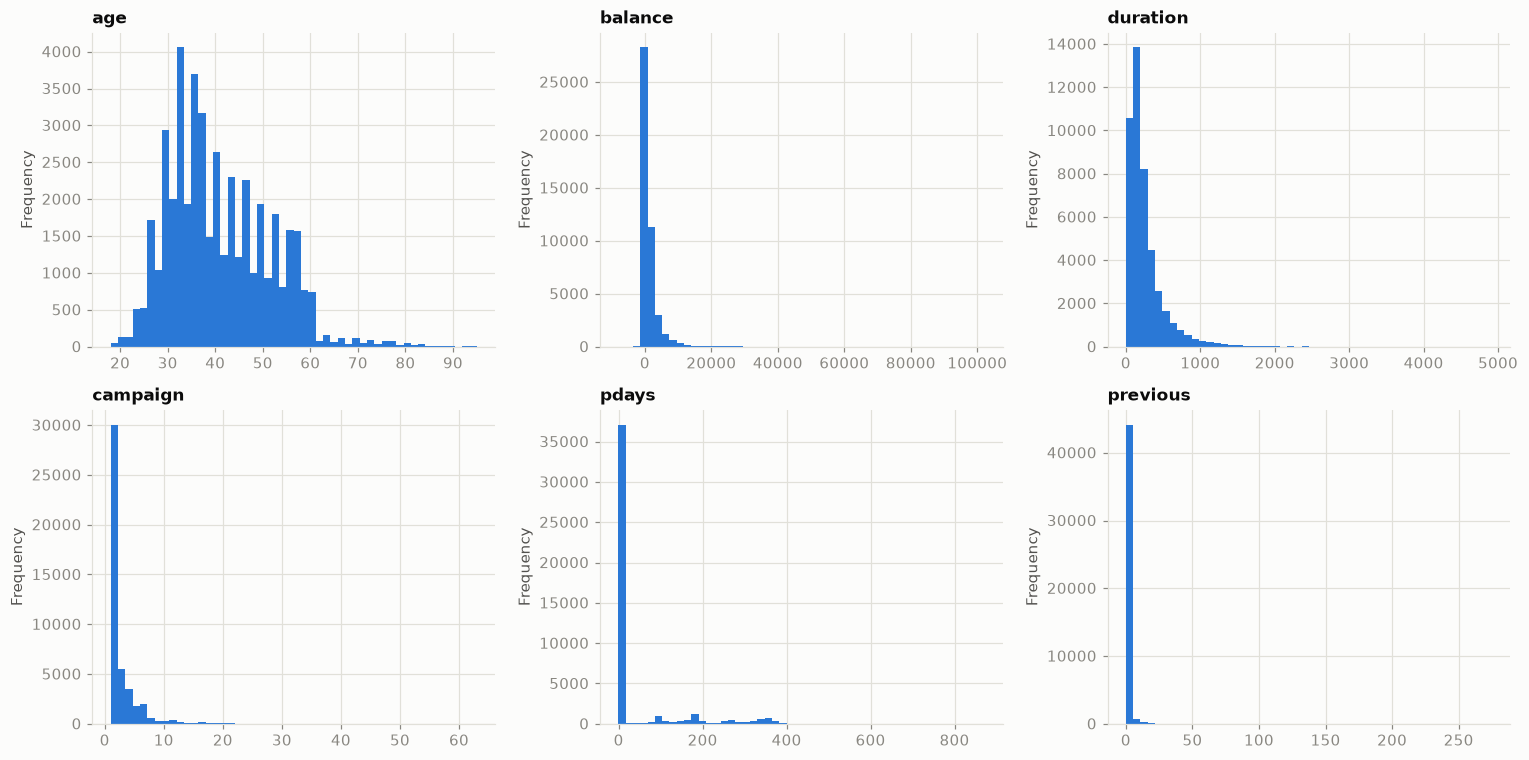

In [4]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, num_cols):
    df[c].plot.hist(bins=50, ax=ax)
    ax.set_title(c)
plt.tight_layout()

**Notes**
- `balance`, `duration`, `campaign` and `previous` are right-skewed (mean well above median, extreme maxima) – prefer medians or log transforms.
- Negative `balance` values are real overdrafts.
- `pdays = -1` is a sentinel for "not previously contacted".

In [5]:
print('share of pdays == -1:', round((df.pdays == -1).mean(), 3))
df.loc[df.pdays != -1, 'pdays'].describe().round(1)

share of pdays == -1: 0.817


count    8257.0
mean      224.6
std       115.3
min         1.0
25%       133.0
50%       194.0
75%       327.0
max       871.0
Name: pdays, dtype: float64

## Categorical columns (% of rows)

In [6]:
cat_cols = df.select_dtypes(exclude='number').columns
for c in cat_cols:
    print(f'\n{c}')
    print(df[c].value_counts(normalize=True).mul(100).round(1).to_string())


job
job
blue-collar      21.5
management       20.9
technician       16.8
admin.           11.4
services          9.2
retired           5.0
self-employed     3.5
entrepreneur      3.3
unemployed        2.9
housemaid         2.7
student           2.1
unknown           0.6

marital
marital
married     60.2
single      28.3
divorced    11.5

education
education
secondary    51.3
tertiary     29.4
primary      15.2
unknown       4.1

default
default
no     98.2
yes     1.8

housing
housing
yes    55.6
no     44.4

loan
loan
no     84.0
yes    16.0

contact
contact
cellular     64.8
unknown      28.8
telephone     6.4

month
month
may    30.4
jul    15.3
aug    13.8
jun    11.8
nov     8.8
apr     6.5
feb     5.9
jan     3.1
oct     1.6
sep     1.3
mar     1.1
dec     0.5

poutcome
poutcome
unknown    81.7
failure    10.8
other       4.1
success     3.3

y
y
no     88.3
yes    11.7


## Subscription rate (`y`) by segment

In [7]:
df['subscribed'] = (df.y == 'yes').astype(int)
print(f'overall: {df.subscribed.mean():.1%}')
df.groupby('job').subscribed.mean().mul(100).round(1).sort_values()

overall: 11.7%


job
blue-collar       7.3
entrepreneur      8.3
housemaid         8.8
services          8.9
technician       11.1
self-employed    11.8
unknown          11.8
admin.           12.2
management       13.8
unemployed       15.5
retired          22.8
student          28.7
Name: subscribed, dtype: float64

Text(0.0, 1.0, 'Subscription rate by job')

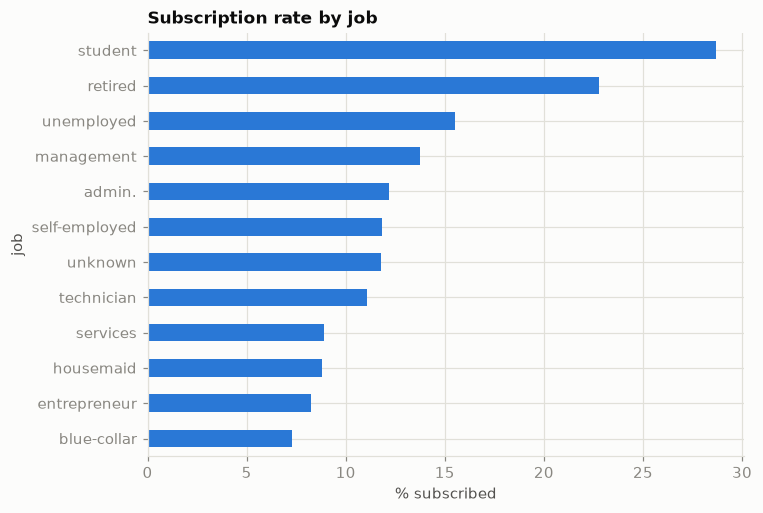

In [8]:
df.groupby('job').subscribed.mean().mul(100).sort_values().plot.barh(figsize=(7, 5))
plt.xlabel('% subscribed')
plt.title('Subscription rate by job')

**Caveats**
- `y` is imbalanced (~11.7% yes).
- `duration` is only known after the call, so it should not be used to predict `y`.

---
# Deep dive: hidden patterns

Everything below goes beyond the basic descriptives. Headline findings are in the markdown cells; each is backed by the code cell above it.

## 1. The rows are in chronological order – and the data spans ~3 years
The file has no year column, but the rows are sorted by time (May → Dec, then Jan → Dec, …). Counting each time the month number wraps around gives an inferred year: **May 2008 → Nov 2010**. This matches the public documentation of this dataset, but the year is inferred, not given, so treat it as approximate (a few early rows in Oct/Dec 2008 are slightly out of order).

In [9]:
mo = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
df['m'] = df.month.map({m: i + 1 for i, m in enumerate(mo)})

year, prev, years = 2008, df.m.iloc[0], []
for m in df.m:
    if m < prev - 3:          # month number wrapped around -> new year
        year += 1
    years.append(year)
    prev = m
df['year'] = years
df['ym'] = df.year.astype(str) + '-' + df.m.astype(str).str.zfill(2)

by_year = df.groupby('year').agg(calls=('subscribed', 'size'), subscribed=('subscribed', 'mean'))
by_year['subscribed'] = (by_year.subscribed * 100).round(1)
by_year

,calls,subscribed
year,,
2008,27729,5.1
2009,14862,17.1
2010,2620,51.6


,calls,rate,unknown_contact,prior_contact,avg_calls_per_client
ym,,,,,
2008-05,7957,0.032,1.000,0.000,2.539
2008-06,4486,0.045,1.000,0.000,3.389
2008-07,6380,0.060,0.037,0.000,3.639
2008-08,5215,0.055,0.002,0.000,4.358
2008-10,80,0.612,0.325,0.088,1.000
2008-11,3598,0.061,0.013,0.254,1.922
2008-12,13,0.077,0.231,0.000,1.000
2009-01,1176,0.032,0.000,0.314,1.629
2009-02,2296,0.111,0.000,0.292,2.461


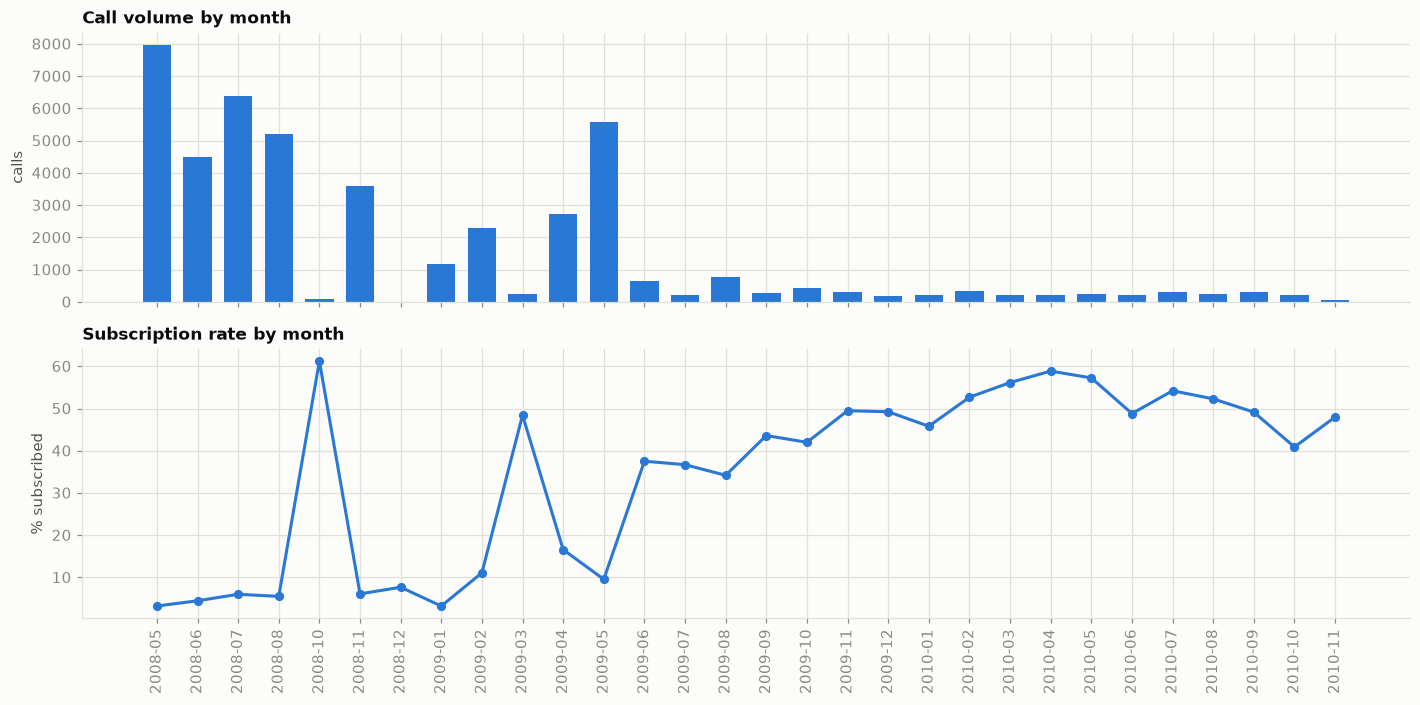

In [10]:
t = df.groupby('ym').agg(calls=('subscribed', 'size'), rate=('subscribed', 'mean'),
                        unknown_contact=('contact', lambda c: (c == 'unknown').mean()),
                        prior_contact=('poutcome', lambda c: (c != 'unknown').mean()),
                        avg_calls_per_client=('campaign', 'mean'))
fig, (a1, a2) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
a1.bar(t.index, t.calls, color=BLUE, width=0.7); a1.set_ylabel('calls'); a1.set_title('Call volume by month')
a2.plot(t.index, t.rate * 100, color=BLUE, marker='o', lw=2, ms=5); a2.set_ylabel('% subscribed'); a2.set_title('Subscription rate by month')
a2.tick_params(axis='x', rotation=90); plt.tight_layout()
t.round(3)

**Finding – the campaign changed strategy over time.** Subscription rate climbs from ~5% (2008) to ~17% (2009) to ~52% (2010) while call volume collapses (27.7k → 14.9k → 2.6k). The bank moved from mass dialling to far fewer, better-targeted calls. In 2010 over 60% of those called had been contacted before.

**Implication:** the headline "month effect" (March, Sept, Oct, Dec at 44–52% vs May at 7%) is mostly a *time/campaign-phase* effect, not seasonality. May is low because it is dominated by the 2008 mass-calling phase (8k of its 13.8k calls); the high months are the small, targeted 2009–2010 pushes. Calendar-month results should not be read as "clients are more receptive in autumn".

In [11]:
print('subscription rate by calendar month x year (%)')
(df.pivot_table(index='m', columns='year', values='subscribed', aggfunc='mean') * 100).round(1)

subscription rate by calendar month x year (%)


year,2008,2009,2010
m,,,
1,NaN,3.2,45.8
2,NaN,11.1,52.7
3,NaN,48.4,56.2
4,NaN,16.6,58.9
5,3.2,9.6,57.3
6,4.5,37.5,48.8
7,6.0,36.7,54.2
8,5.5,34.2,52.3
9,NaN,43.6,49.2


Within a single calendar month the year dominates (e.g. June: 4.5% → 37.5% → 48.8%). Calendar month on its own adds little once you know the year.

## 2. `contact = unknown` is a data-collection artifact, not a customer trait
The 29% of rows with unknown contact type look like a very weak segment (4% subscribe vs ~15% for cellular).

In [12]:
print('share of rows with contact == unknown, by month (%)')
print((pd.crosstab(df.month, df.contact, normalize='index')['unknown'] * 100).round(0).reindex(mo).to_string())
print('\nMay-Jun 2008 only:')
mj = df[(df.year == 2008) & df.month.isin(['may', 'jun'])]
print('unknown share:', round((mj.contact == 'unknown').mean(), 3), '| rate:', round(mj.subscribed.mean(), 3), '| rows:', len(mj))

share of rows with contact == unknown, by month (%)
month
jan     1.0
feb     0.0
mar     1.0
apr     0.0
may    58.0
jun    85.0
jul     4.0
aug     1.0
sep     8.0
oct     7.0
nov     1.0
dec     1.0

May-Jun 2008 only:
unknown share: 1.0 | rate: 0.037 | rows: 12443


**Finding:** every one of the ~12.4k calls in May–Jun 2008 has `contact = unknown`, and that phase also had the lowest conversion. So `unknown` is a proxy for "early mass-calling period", not a client behaviour. It will rank as a strong predictor in a model for that reason, but it isn't something you can act on.

## 3. Prior outcome is the strongest single signal

In [13]:
(df.groupby('poutcome').subscribed.agg(['mean', 'size']).assign(mean=lambda d: (d['mean'] * 100).round(1)))

,mean,size
poutcome,,
failure,12.6,4901
other,16.7,1840
success,64.7,1511
unknown,9.2,36959


In [14]:
print('rate by number of previous contacts (%)')
df['prev_bin'] = pd.cut(df.previous, [-1, 0, 1, 2, 5, 10, 1000])
print(df.groupby('prev_bin', observed=True).subscribed.agg(['mean', 'size']).assign(mean=lambda d: (d['mean'] * 100).round(1)))
print('\nrate by days since last contact (clients contacted before)')
d = df[df.pdays > 0]
print(d.groupby(pd.cut(d.pdays, [0, 30, 90, 180, 365, 900]), observed=True).subscribed.agg(['mean', 'size']).assign(mean=lambda x: (x['mean'] * 100).round(1)))

rate by number of previous contacts (%)
            mean   size
prev_bin               
(-1, 0]      9.2  36954
(0, 1]      21.0   2772
(1, 2]      21.7   2106
(2, 5]      25.3   2315
(5, 10]     29.4    770
(10, 1000]  18.4    294

rate by days since last contact (clients contacted before)
            mean  size
pdays                 
(0, 30]     14.9   188
(30, 90]    42.1   530
(90, 180]   27.4  2480
(180, 365]  17.8  4416
(365, 900]  29.2   643


**Findings**
- Clients who said yes in a previous campaign subscribe **65%** of the time vs 9% for never-contacted (7× lift). Only 3.3% of rows are in this group, so it is high-impact but small.
- Past *failures* still convert better (12.6%) than never-contacted (9.2%).
- **Diminishing returns on follow-up:** rate rises with 1–10 prior contacts (21% → 29%) but drops back to 18% beyond 10 – over-contacted clients.
- **Recency sweet spot:** clients last contacted 30–90 days ago convert at 42%, vs 18% at 6–12 months. A ~1–3 month follow-up window looks best (the ≤30-day group is only 188 rows, so treat it as indicative).

## 4. Diminishing (and then negative) returns on call attempts in the current campaign

campaign,1,2,3,4,5,6,7,8,9,10,11,12,13
mean,14.6,11.2,11.2,9.0,7.9,7.1,6.4,5.9,6.4,5.3,8.0,2.6,4.5
size,17544.0,12505.0,5521.0,3522.0,1764.0,1291.0,735.0,540.0,327.0,266.0,201.0,155.0,133.0


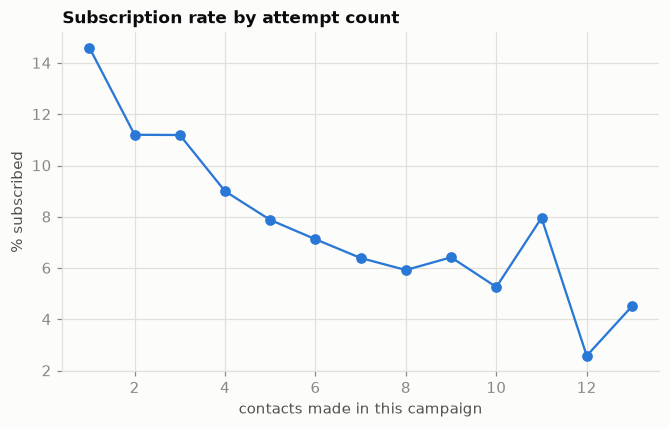

In [15]:
x = df.groupby('campaign').subscribed.agg(['mean', 'size'])
x = x[x['size'] >= 100]
ax = (x['mean'] * 100).plot(marker='o', figsize=(7, 4))
ax.set_xlabel('contacts made in this campaign'); ax.set_ylabel('% subscribed'); ax.set_title('Subscription rate by attempt count')
(x.assign(mean=(x['mean'] * 100).round(1))).T

**Finding:** the first contact converts best (14.6%); the rate decays steadily to ~5% by the 10th attempt. Persistence beyond ~3 attempts has poor payoff, and the heavily called clients are probably the least interested.

## 5. Age has a U-shaped effect – and it is age itself, not just job

,rate,n,median_balance
age_bin,,,
"(17, 25]",24.0,1336,361.0
"(25, 30]",14.5,5694,341.0
"(30, 35]",10.6,9877,391.0
"(35, 40]",9.8,7810,439.0
"(40, 50]",9.1,11239,463.0
"(50, 60]",10.1,8067,583.0
"(60, 70]",40.5,701,1295.0
"(70, 100]",44.8,487,1388.0


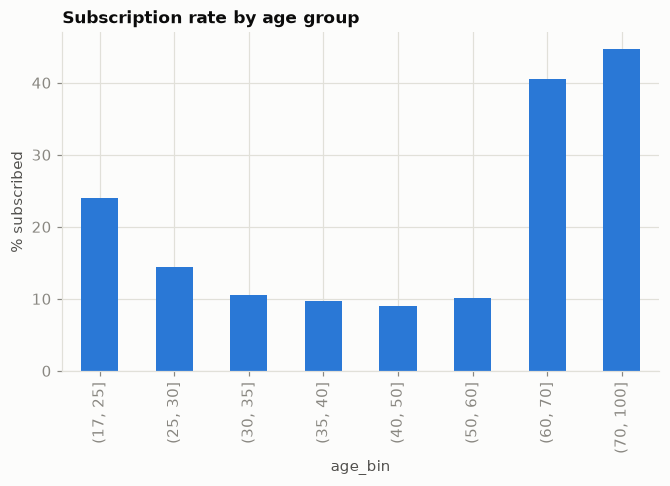

In [16]:
df['age_bin'] = pd.cut(df.age, [17, 25, 30, 35, 40, 50, 60, 70, 100])
a = df.groupby('age_bin', observed=True).agg(rate=('subscribed', 'mean'), n=('subscribed', 'size'), median_balance=('balance', 'median'))
a['rate'] = (a.rate * 100).round(1)
ax = a.rate.plot.bar(figsize=(7, 4)); ax.set_ylabel('% subscribed'); ax.set_title('Subscription rate by age group')
a

In [17]:
print('retired share of clients 60+:', round((df[df.age >= 60].job == 'retired').mean(), 2))
print('\nrate among 60+, retired vs not:')
print(df[df.age >= 60].groupby(df.job == 'retired').subscribed.agg(['mean', 'size']).round(3))
print('\nrate for under-60s: retired vs not:')
print(df[df.age < 60].groupby(df.job == 'retired').subscribed.agg(['mean', 'size']).round(3))

retired share of clients 60+: 0.61

rate among 60+, retired vs not:
        mean  size
job               
False  0.274   694
True   0.376  1090

rate for under-60s: retired vs not:
        mean   size
job                
False  0.108  42253
True   0.090   1174


**Finding:** rate is ~24% under 25, bottoms out at ~9–10% for ages 35–60, then jumps to **40–45% for 60+** (n = 1,784; 34% overall for ages 60+). Median balance for 60+ is ~3× that of 40–50 year-olds. 61% of 60+ clients are retired, but the effect is not just a job label: non-retired clients aged 60+ still subscribe at 27%, while retirees under 60 subscribe at only 9%. Age (and the wealth/time that comes with it) matters more than the retired label. Age is nearly uncorrelated with `y` linearly (r = 0.03), which is why a plain correlation matrix hides this pattern.

> **Update from Part 2:** this age effect is concentrated in 2009 (60+ at 36% vs 16%); in 2008 and 2010 there is no gap between 60+ and younger clients. The jump at exactly age 60 suggests deliberate targeting. See the robustness check and regression in Part 2.

## 6. Loans: household debt strongly suppresses subscription, and the effects stack

In [18]:
t = df.pivot_table(index='housing', columns='loan', values='subscribed', aggfunc=['mean', 'size'])
(t['mean'] * 100).round(1), t['size']

(loan       no  yes
 housing           
 no       18.2  7.6
 yes       8.0  6.1,
 loan        no   yes
 housing             
 no       17204  2877
 yes      20763  4367)

In [19]:
print('rate by housing x loan x contact (%), no-debt vs debt')
g = df[df.contact != 'unknown'].groupby(['housing', 'loan']).subscribed.agg(['mean', 'size'])
g['mean'] = (g['mean'] * 100).round(1); g

rate by housing x loan x contact (%), no-debt vs debt


mean   size
housing loan             
no      no    21.3  14053
        yes    8.3   2365
yes     no    10.4  12926
        yes    7.6   2847

**Finding:** clients with **no housing loan and no personal loan** subscribe at **18.2%**, versus 8.0% (housing only), 7.6% (personal only) and 6.1% (both). Excluding the artifact-heavy `unknown` contact rows, no-debt cellular clients reach ~21.5%. Debt-free clients are the natural target.

> **Update from Part 2:** the debt gap is real but inflated by time. Within 2009 the gap is large (28.8% vs 10.5%), but in 2008 and 2010 it is small. After controlling for year, a housing loan reduces the odds by about 30% (OR 0.70), not the 50% (OR 0.51) the raw numbers imply.

## 7. Education × job interaction

In [20]:
(df.pivot_table(index='education', columns='job', values='subscribed', aggfunc='mean') * 100).round(0)

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
education,,,,,,,,,,,,
primary,6.0,6.0,7.0,8.0,7.0,22.0,4.0,8.0,36.0,8.0,13.0,6.0
secondary,12.0,8.0,10.0,9.0,9.0,21.0,7.0,9.0,30.0,10.0,15.0,13.0
tertiary,17.0,16.0,8.0,13.0,15.0,28.0,16.0,12.0,26.0,15.0,19.0,10.0
unknown,11.0,7.0,9.0,9.0,20.0,25.0,13.0,13.0,26.0,10.0,14.0,14.0


**Finding:** education matters most for blue-collar workers (6% primary → 16% tertiary) and admin/management; it hardly matters for retirees (21–28%) or students (26–36%), who convert well regardless. A blue-collar worker with tertiary education looks like a very different prospect from the typical blue-collar profile.

## 8. Call duration: the strongest predictor, but not usable

In [21]:
df['dur_bin'] = pd.cut(df.duration, [-1, 60, 120, 180, 300, 600, 1000, 5000])
print(df.groupby('dur_bin', observed=True).subscribed.agg(['mean', 'size']).assign(mean=lambda d: (d['mean'] * 100).round(1)))
print('\nmedian duration (sec) by outcome:'); print(df.groupby('y').duration.median())

              mean   size
dur_bin                  
(-1, 60]       0.2   4766
(60, 120]      2.2   9278
(120, 180]     5.8   8616
(180, 300]    10.9  10277
(300, 600]    19.2   8484
(600, 1000]   44.0   2732
(1000, 5000]  59.7   1058

median duration (sec) by outcome:
y
no     164.0
yes    426.0
Name: duration, dtype: float64


**Finding:** calls under 1 minute almost never convert (0.2%); calls over 10 minutes convert at 44–60%. Median duration is 426s for yes vs 164s for no. This is outcome leakage (a client who is interested stays on the phone) – but it is useful operationally: the first ~2 minutes are decisive.

## 9. Which features matter? Association strength and a model check

age         0.025
balance     0.053
day        -0.028
duration    0.395
campaign   -0.073
pdays       0.104
previous    0.093


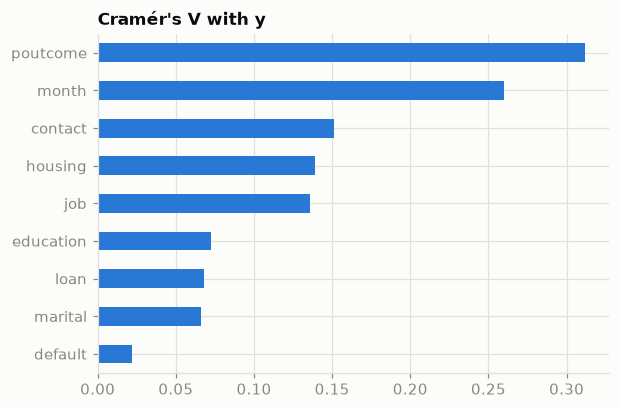

In [22]:
import numpy as np
from scipy import stats

def cramers_v(a, b):
    t = pd.crosstab(a, b); chi2 = stats.chi2_contingency(t)[0]
    return np.sqrt(chi2 / t.values.sum() / (min(t.shape) - 1))

cats = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
assoc = pd.Series({c: cramers_v(df[c], df.y) for c in cats}).sort_values()
assoc.plot.barh(figsize=(6, 4)); plt.title("Cramér's V with y")
print(df[['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']].corrwith(df.subscribed).round(3).to_string())

In [23]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

feats = df.drop(columns=['y', 'subscribed', 'm', 'year', 'ym', 'age_bin', 'prev_bin', 'dur_bin'])
X = pd.get_dummies(feats, dtype=int)
cv = StratifiedKFold(5, shuffle=True, random_state=0)
auc = lambda cols: cross_val_score(HistGradientBoostingClassifier(), X[cols], df.subscribed, cv=cv, scoring='roc_auc').mean()

all_cols = list(X.columns)
no_dur = [c for c in all_cols if c != 'duration']
no_timing = [c for c in no_dur if not c.startswith('month_') and c != 'day']
pd.Series({'all features': auc(all_cols), 'without duration': auc(no_dur), 'without duration, month, day': auc(no_timing)}).round(3)

all features                    0.936
without duration                0.799
without duration, month, day    0.763
dtype: float64

**Findings**
- Strongest associations with `y`: `poutcome` (V=0.31), `month` (0.26; a proxy for campaign phase, see §1), `contact` (0.15; artifact, see §2), `housing` (0.14), `job` (0.14). `duration` is the only numeric variable with a notable linear correlation (r=0.40).
- A gradient-boosting model reaches AUC ≈ 0.94 with `duration`, ≈ **0.80 without** it, and ≈ 0.76 once the timing variables (month, day) are also removed. Real pre-call signal exists, but a good part of it is campaign timing rather than client characteristics.
- Linear correlations are weak across the board (all |r| < 0.11 except duration) because the important relationships are non-linear (age U-shape, attempt decay, prior outcome).

## 10. Smaller observations

In [24]:
print('pdays and previous are almost the same variable (Spearman):', round(df.pdays.corr(df.previous, method='spearman'), 2))
print('\nrate by day of month (days with >= 400 calls):')
d = df.groupby('day').subscribed.agg(['mean', 'size']); d = d[d['size'] >= 400]
print((d['mean'] * 100).round(1).sort_values(ascending=False).head(5).to_string())
print('\nextreme outliers:')
print(df[df.previous > 50][['previous', 'pdays', 'poutcome', 'y']])
print('\nmedian balance, defaulters vs not:'); print(df.groupby('default').balance.median())
print('\nzero-duration calls:', (df.duration == 0).sum(), '| calls <= 5s:', (df.duration <= 5).sum(), 'all non-subscribers:', df[df.duration <= 5].y.eq('no').all())

pdays and previous are almost the same variable (Spearman): 0.99

rate by day of month (days with >= 400 calls):
day
10    23.1
30    17.3
22    17.0
3     16.5
4     15.9

extreme outliers:
       previous  pdays poutcome    y
28886        51    256  failure   no
29182       275    262    other   no
38326        58    353    other  yes
44089        55    776  failure  yes

median balance, defaulters vs not:
default
no     468.0
yes     -7.0
Name: balance, dtype: float64

zero-duration calls: 3 | calls <= 5s: 62 all non-subscribers: True


- `pdays` and `previous` are ~99% rank-correlated (both are zero/-1 for the same never-contacted clients), so one is redundant for modelling.
- Day-of-month differences exist (e.g. early-month days convert better) but are modest and likely entangled with the campaign-phase effect – don't over-read them.
- Defaulters have a median balance of −$7 vs +$468 for non-defaulters, and convert at half the rate (6.4% vs 11.8%) – though only 815 clients (1.8%) are in default.
- Outliers (e.g. `previous` = 275, balances above $98k) look like genuine extremes or data-entry errors; there are only a handful and they won't affect conclusions, but they do inflate means.

## Summary of hidden patterns
1. **Time is the biggest hidden driver**: conversion went 5% → 17% → 52% as the campaign shifted from mass to targeted calling. "Month" and "contact unknown" are largely proxies for this.
2. **Prior success** (65%) and a **1–3 month follow-up window** are the strongest actionable signals.
3. **Call attempts have diminishing returns**: 14.6% on the first call, ~5% by the tenth.
4. **U-shaped age effect**: under-25s and 60+ clients respond far better than the middle-aged majority.
5. **Debt-free clients** (no housing or personal loan) convert at roughly double the rate of indebted ones.
6. **Duration** is highly predictive but only known after the call, so exclude it from any predictive model.

> **Update from Part 2:** items 4 and 5 (age and debt) are real but depend heavily on *when* the client was called; see Part 2 for the corrected, controlled estimates.

---
# Visual gallery
Charts for the descriptive statistics and the patterns above. Conventions: blue = the main series, orange = the contrast series (e.g. *not subscribed*), grey = reference lines, single-hue blue ramp for magnitude, blue↔red with a neutral midpoint for signed values. Every chart has a table form in the cells above.

## A. Distributions of the numeric variables

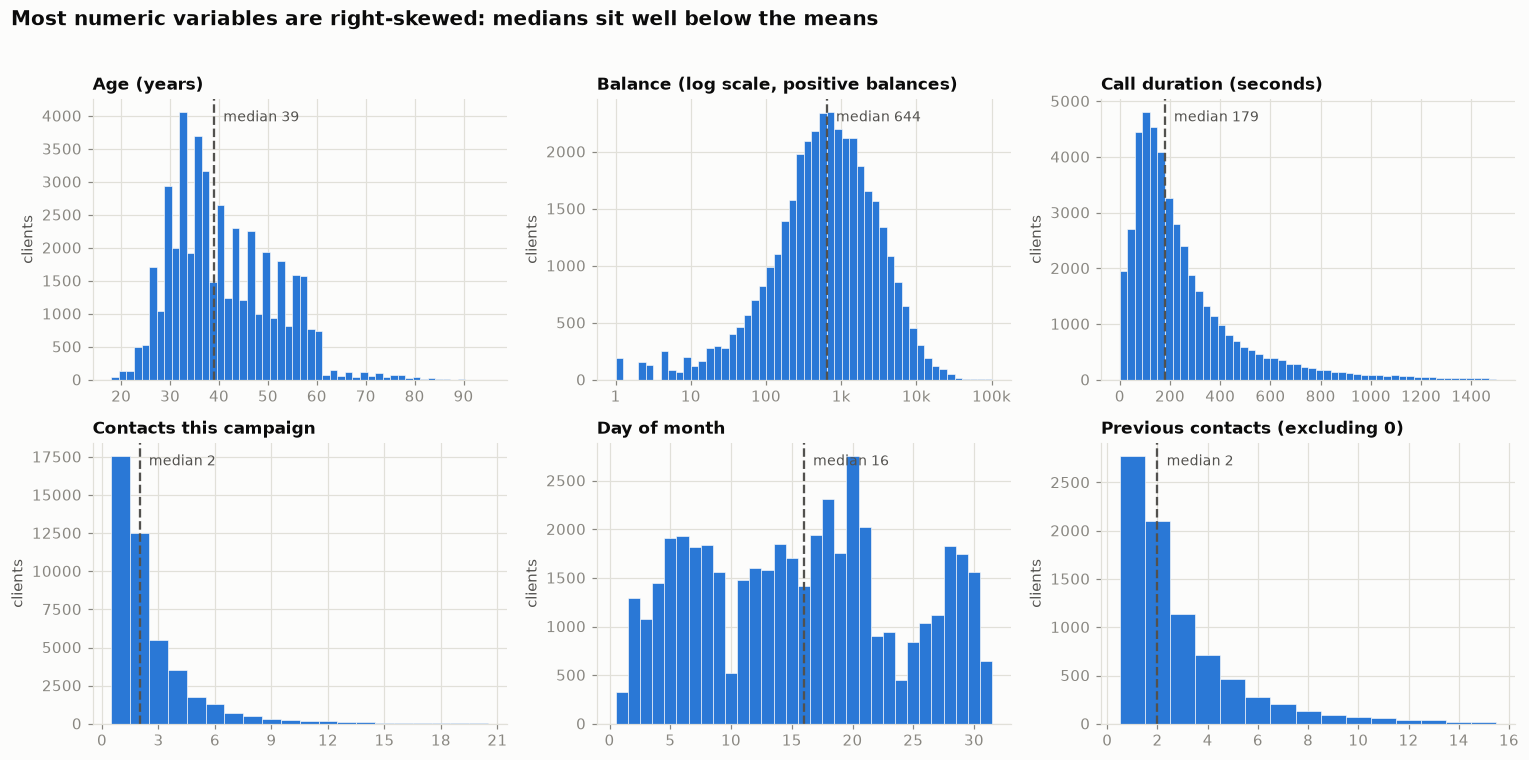

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
specs = [('age', 'Age (years)', False), ('balance', 'Balance (log scale, positive balances)', True),
         ('duration', 'Call duration (seconds)', False), ('campaign', 'Contacts this campaign', False),
         ('day', 'Day of month', False), ('previous', 'Previous contacts (excluding 0)', False)]
for ax, (c, label, log) in zip(axes.flat, specs):
    s = df[c]
    if c == 'balance': s = s[s > 0]
    if c == 'previous': s = s[(s > 0) & (s <= 15)]
    if c in ('duration',): s = s[s <= 1500]
    if c == 'campaign': s = s[s <= 20]
    if log:
        ax.hist(np.log10(s), bins=50, color=BLUE, edgecolor=SURFACE, linewidth=0.4)
        ax.set_xticks([0, 1, 2, 3, 4, 5]); ax.set_xticklabels(['1', '10', '100', '1k', '10k', '100k'])
        med = np.log10(s.median())
    else:
        if c in ('campaign', 'day', 'previous'):
            ax.hist(s, bins=np.arange(s.min() - 0.5, s.max() + 1.5, 1), color=BLUE, edgecolor=SURFACE, linewidth=0.4)
        else:
            ax.hist(s, bins=50, color=BLUE, edgecolor=SURFACE, linewidth=0.4)
        med = s.median()
    ax.axvline(med, color=INK2, lw=1.5, ls='--')
    ax.annotate(f'median {s.median():,.0f}', (med, ax.get_ylim()[1] * 0.92), xytext=(6, 0), textcoords='offset points', color=INK2, fontsize=9)
    ax.set_title(label); ax.set_ylabel('clients')
    if c in ('campaign', 'previous'): ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
fig.suptitle('Most numeric variables are right-skewed: medians sit well below the means', x=0.01, ha='left', fontsize=13, fontweight='bold', color=INK)
plt.tight_layout(rect=[0, 0, 1, 0.96])

Tails are clipped for readability (duration ≤ 1,500s, campaign ≤ 20, previous ≤ 15 contacts); balance uses a log axis and positive values only (8% of clients have a balance ≤ 0).

## B. Who is in the data? (composition of the categorical variables)

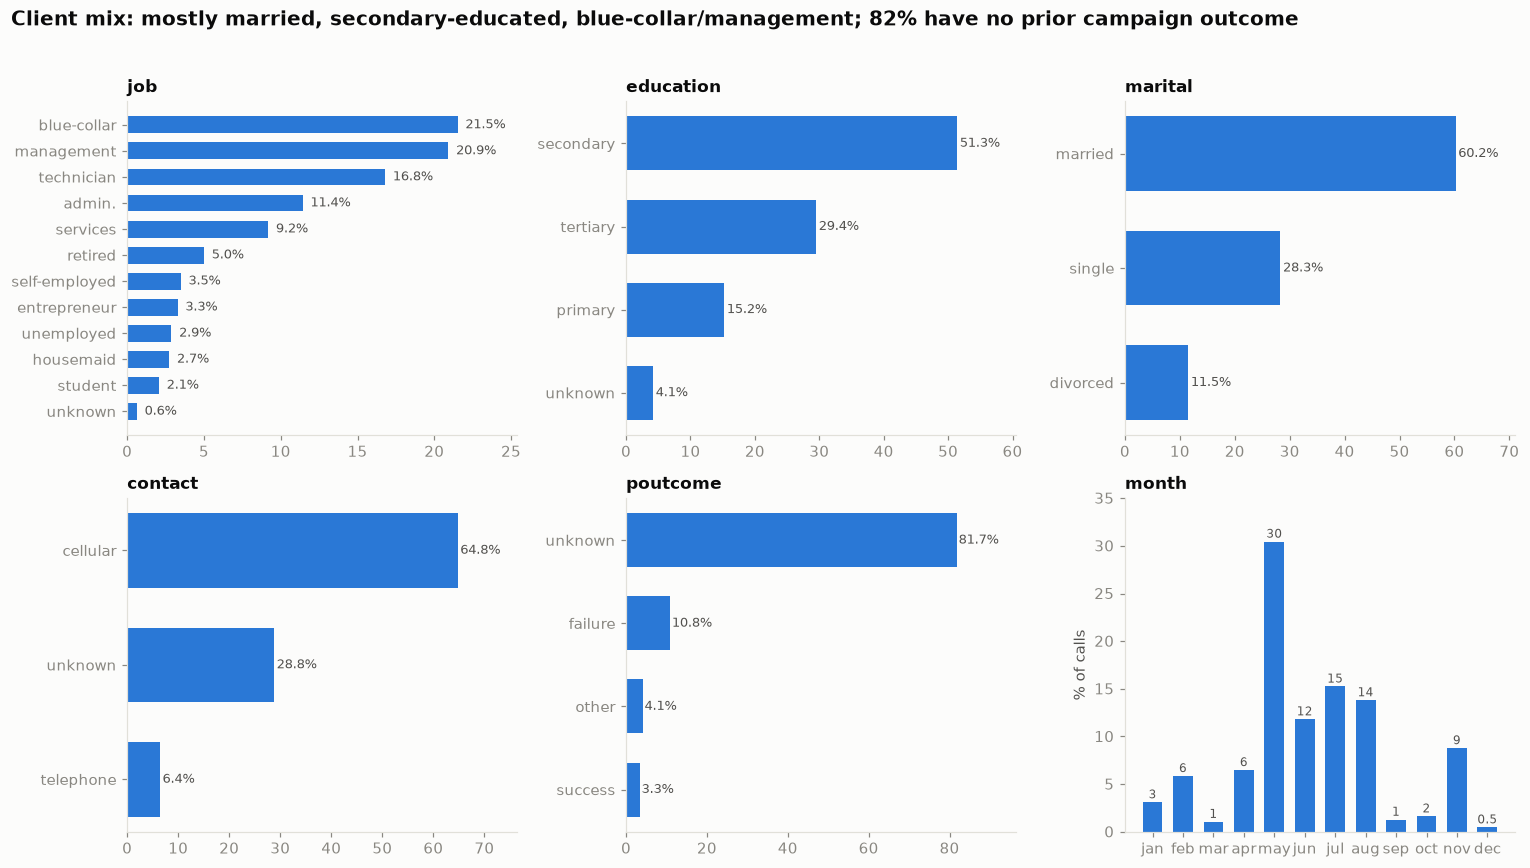

In [26]:
cols = ['job', 'education', 'marital', 'contact', 'poutcome', 'month']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, c in zip(axes.flat, cols):
    s = df[c].value_counts(normalize=True) * 100
    if c == 'month': s = s.reindex(mo)
    else: s = s.sort_values()
    ax.barh(s.index, s.values, color=BLUE, height=0.65) if c != 'month' else ax.bar(s.index, s.values, color=BLUE, width=0.65)
    ax.set_title(c)
    for i, v in enumerate(s.values):
        if c == 'month': ax.text(i, v + 0.4, f'{v:.0f}' if v >= 1 else f'{v:.1f}', ha='center', fontsize=8, color=INK2)
        else: ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8.5, color=INK2)
    ax.grid(False); ax.set_xlim(0, s.max() * 1.18) if c != 'month' else ax.set_ylim(0, s.max() * 1.15)
    if c == 'month': ax.set_ylabel('% of calls')
fig.suptitle('Client mix: mostly married, secondary-educated, blue-collar/management; 82% have no prior campaign outcome', x=0.01, ha='left', fontsize=13, fontweight='bold', color=INK)
plt.tight_layout(rect=[0, 0, 1, 0.96])

## C. Subscription rate by segment (ranked, against the 11.7% average)

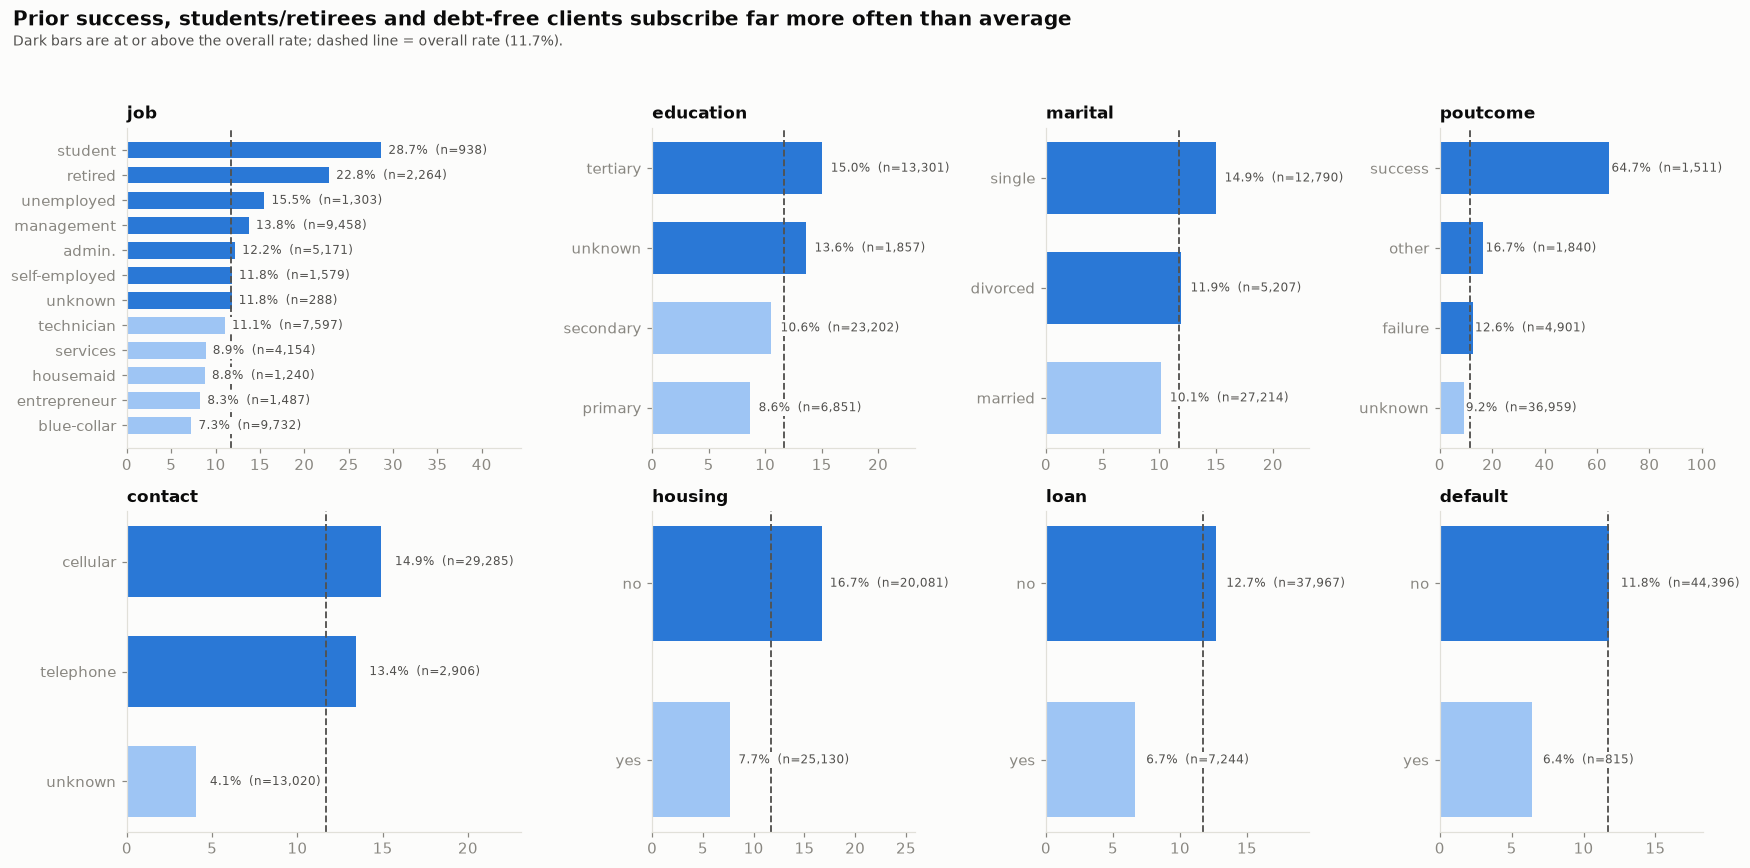

In [27]:
overall = df.subscribed.mean() * 100
def seg_rates(col, order=None):
    g = df.groupby(col).subscribed.agg(['mean', 'size']); g['mean'] *= 100
    return g.sort_values('mean') if order is None else g.loc[order]

panels = [('job', None), ('education', None), ('marital', None), ('poutcome', None), ('contact', None), ('housing', None), ('loan', None), ('default', None)]
fig, axes = plt.subplots(2, 4, figsize=(16, 8), gridspec_kw={'width_ratios': [1.5, 1, 1, 1]})
for ax, (c, o) in zip(axes.flat, panels):
    g = seg_rates(c, o)
    colors = [BLUE if v >= overall else '#9ec5f4' for v in g['mean']]
    ax.barh(g.index.astype(str), g['mean'], color=colors, height=0.65)
    ax.axvline(overall, color=INK2, lw=1.2, ls='--')
    for i, (v, n) in enumerate(zip(g['mean'], g['size'])):
        ax.text(v + 0.8, i, f'{v:.1f}%  (n={n:,})', va='center', fontsize=8, color=INK2, bbox=dict(fc=SURFACE, ec='none', pad=1.2), zorder=5)
    ax.set_title(c); ax.set_xlim(0, max(g['mean']) * 1.55); ax.grid(False)
fig.suptitle('Prior success, students/retirees and debt-free clients subscribe far more often than average', x=0.01, ha='left', fontsize=13, fontweight='bold', color=INK)
fig.text(0.01, 0.94, f'Dark bars are at or above the overall rate; dashed line = overall rate ({overall:.1f}%).', fontsize=9, color=INK2)
plt.tight_layout(rect=[0, 0, 1, 0.93])

## D. Rate curves with uncertainty (age, attempts, balance, duration)
Bands are 95% Wilson intervals, so thin groups show up as wide bands instead of false precision.

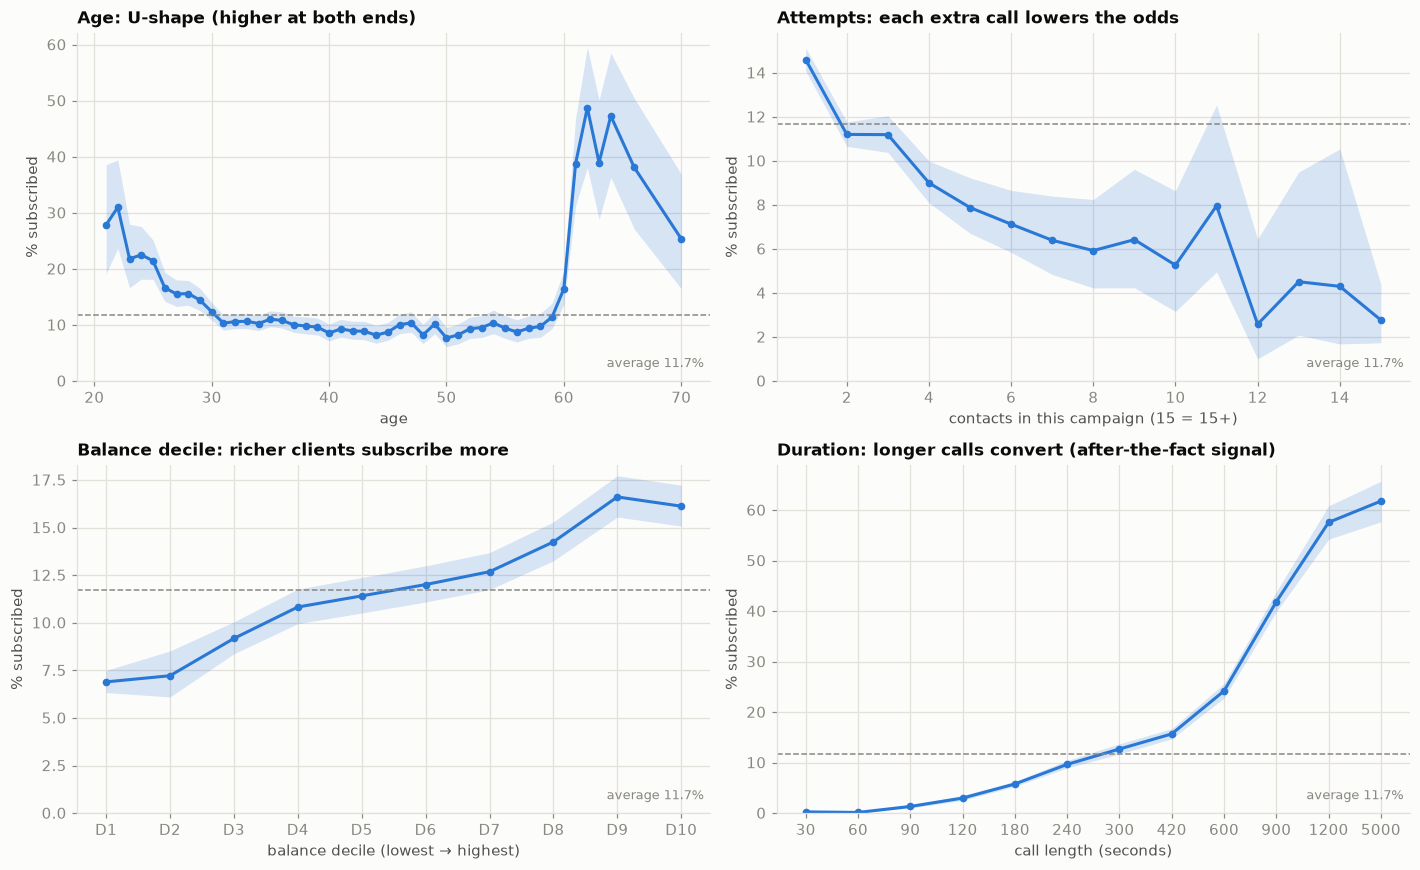

In [28]:
def wilson(k, n, z=1.96):
    p = k / n; d = 1 + z**2 / n
    c = (p + z**2 / (2 * n)) / d; h = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / d
    return (c - h) * 100, (c + h) * 100

def rate_curve(ax, key, title, xlabel, xtick_labels=None, min_n=60):
    g = df.groupby(key, observed=True).subscribed.agg(['sum', 'size', 'mean']); g = g[g['size'] >= min_n]
    lo, hi = wilson(g['sum'], g['size'])
    x = np.arange(len(g)) if xtick_labels is not None else g.index.astype(float)
    ax.fill_between(x, lo, hi, color=BLUE, alpha=0.18, lw=0)
    ax.plot(x, g['mean'] * 100, color=BLUE, lw=2, marker='o', ms=4)
    ax.axhline(overall, color=MUTED, lw=1, ls='--'); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('% subscribed'); ax.set_ylim(0, None)
    if xtick_labels is not None: ax.set_xticks(x); ax.set_xticklabels(g.index.astype(str), rotation=35, ha='right')

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
rate_curve(axes[0, 0], 'age', 'Age: U-shape (higher at both ends)', 'age')
rate_curve(axes[0, 1], df.campaign.clip(upper=15), 'Attempts: each extra call lowers the odds', 'contacts in this campaign (15 = 15+)', min_n=60)
df['bal_bin'] = pd.qcut(df.balance, 10, duplicates='drop')
rate_curve(axes[1, 0], 'bal_bin', 'Balance decile: richer clients subscribe more', 'balance decile (lowest → highest)', xtick_labels=True)
axes[1, 0].set_xticklabels([f'D{i+1}' for i in range(10)], rotation=0, ha='center')
df['dur_dec'] = pd.cut(df.duration, [-1, 30, 60, 90, 120, 180, 240, 300, 420, 600, 900, 1200, 5000])
rate_curve(axes[1, 1], 'dur_dec', 'Duration: longer calls convert (after-the-fact signal)', 'call length (seconds)', xtick_labels=True)
axes[1, 1].set_xticklabels([str(i.right) for i in sorted(df.dur_dec.dropna().unique())], rotation=0, ha='center')
for ax in axes.flat: ax.text(0.99, 0.04, f'average {overall:.1f}%', transform=ax.transAxes, ha='right', fontsize=8.5, color=MUTED)
plt.tight_layout()

## E. Yes vs no: how do subscribers differ?

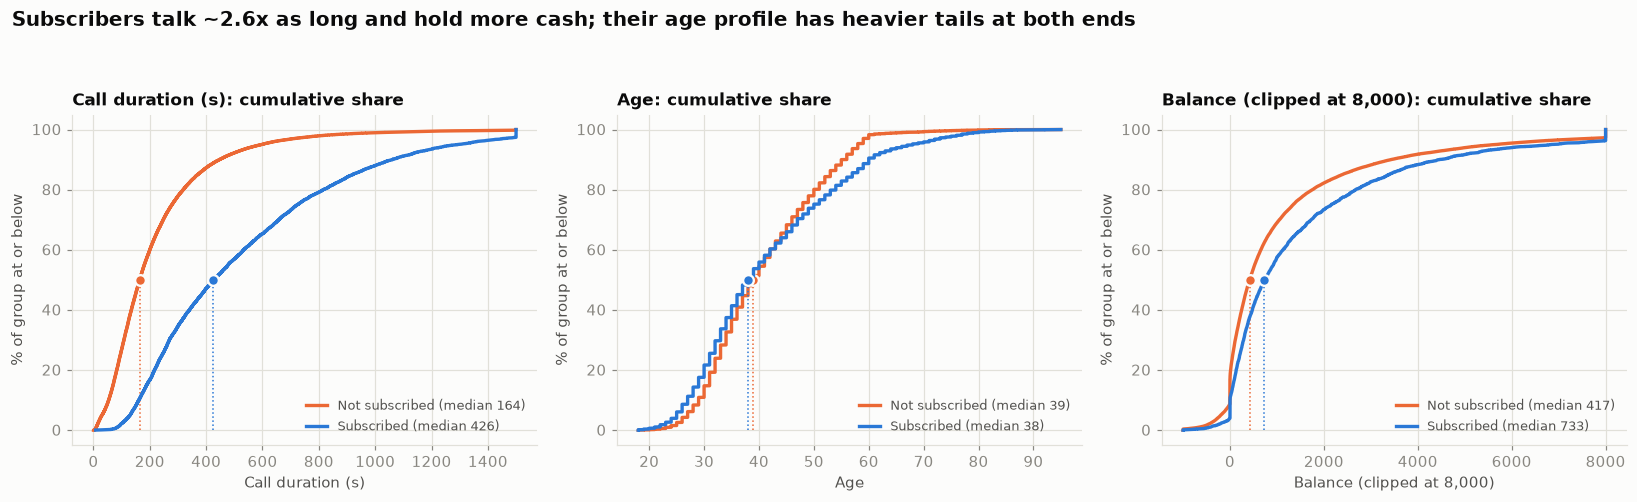

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (c, clip, lab) in zip(axes, [('duration', 1500, 'Call duration (s)'), ('age', 95, 'Age'), ('balance', 8000, 'Balance (clipped at 8,000)')]):
    for val, col, name in [('no', ORANGE, 'Not subscribed'), ('yes', BLUE, 'Subscribed')]:
        s = np.sort(df.loc[df.y == val, c].clip(upper=clip, lower=-1000 if c == 'balance' else None).values)
        line, = ax.plot(s, np.arange(1, len(s) + 1) / len(s) * 100, color=col, lw=2.2)
        m = np.median(s); ax.plot([m, m], [0, 50], color=col, lw=1, ls=':'); ax.plot(m, 50, 'o', color=col, ms=7, mec=SURFACE, mew=1.5)
        line.set_label(f'{name} (median {m:,.0f})')
    ax.legend(loc='lower right', frameon=False, fontsize=8.5, handlelength=1.6)
    ax.set_title(f'{lab}: cumulative share'); ax.set_xlabel(lab); ax.set_ylabel('% of group at or below')
fig.suptitle('Subscribers talk ~2.6x as long and hold more cash; their age profile has heavier tails at both ends', x=0.01, ha='left', fontsize=13, fontweight='bold', color=INK)
plt.tight_layout(rect=[0, 0, 1, 0.92])

Each line is the cumulative distribution for one group; the further right a line sits, the larger that group's values. Dotted drop-lines mark medians.

## F. Heatmaps: where do the pockets of high conversion sit?

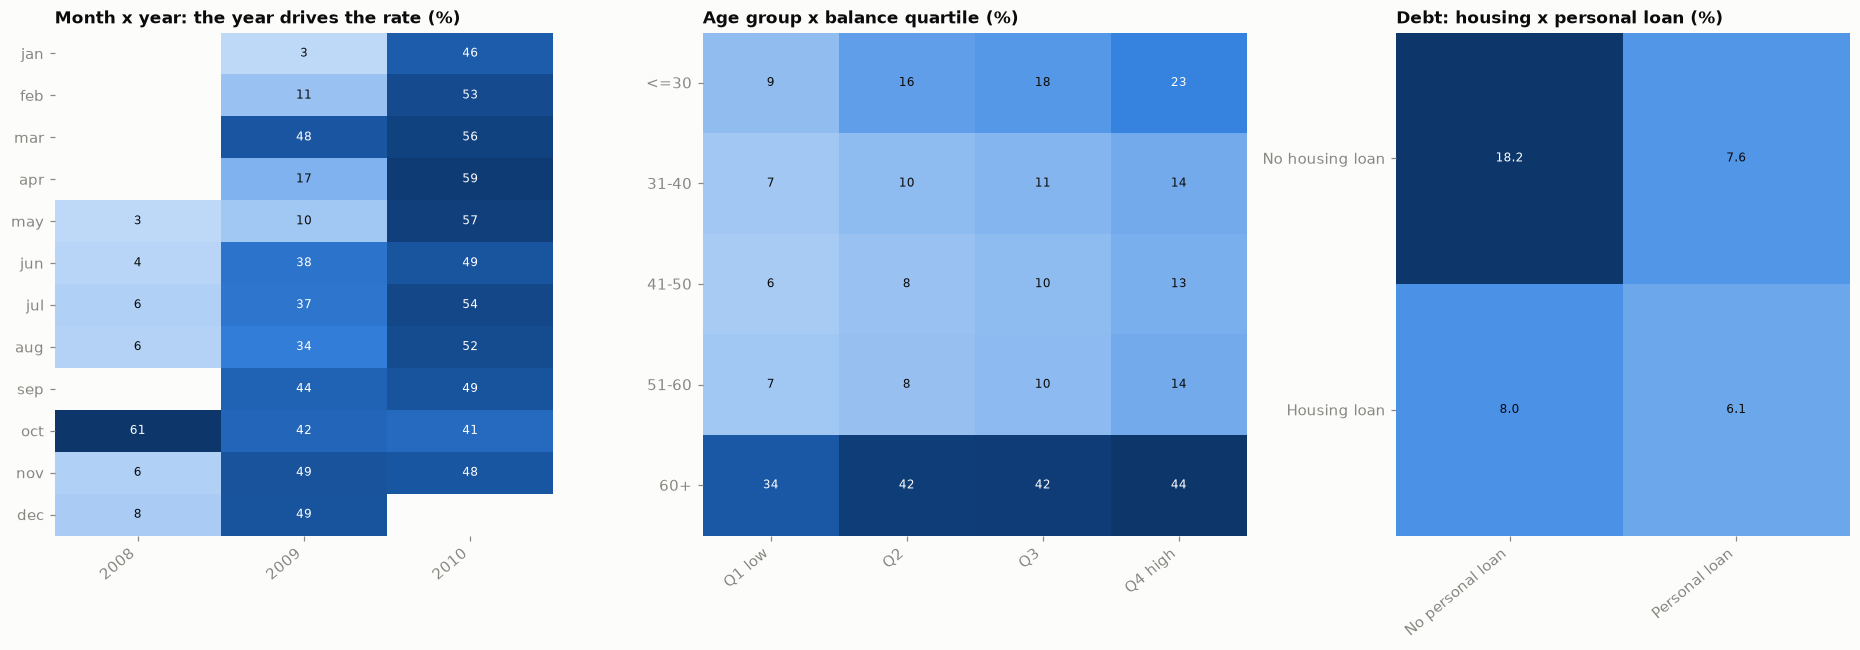

In [30]:
def heat(ax, tbl, title, fmt='{:.0f}', vmax=None, cmap=SEQ, center=None, mask_n=None, sizes=None):
    v = tbl.values.astype(float)
    vmax = np.nanmax(v) if vmax is None else vmax
    im = ax.imshow(v, cmap=cmap, aspect='auto', vmin=0 if center is None else -vmax, vmax=vmax)
    ax.set_xticks(range(tbl.shape[1])); ax.set_xticklabels(tbl.columns, rotation=40, ha='right')
    ax.set_yticks(range(tbl.shape[0])); ax.set_yticklabels(tbl.index)
    ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    for i in range(v.shape[0]):
        for j in range(v.shape[1]):
            if np.isnan(v[i, j]): continue
            rgba = im.cmap(im.norm(v[i, j])); lum = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            ax.text(j, i, fmt.format(v[i, j]), ha='center', va='center', fontsize=8, color='white' if lum < 0.5 else INK)
    ax.set_title(title); return im

fig, axes = plt.subplots(1, 3, figsize=(17, 6), gridspec_kw={'width_ratios': [1.1, 1.2, 1]})
t1 = (df.pivot_table(index='m', columns='year', values='subscribed', aggfunc='mean') * 100)
t1.index = mo[:len(t1.index)]
heat(axes[0], t1, 'Month x year: the year drives the rate (%)')
df['age_g'] = pd.cut(df.age, [17, 30, 40, 50, 60, 100], labels=['<=30', '31-40', '41-50', '51-60', '60+'])
df['bal_g'] = pd.qcut(df.balance, 4, labels=['Q1 low', 'Q2', 'Q3', 'Q4 high'])
t2 = df.pivot_table(index='age_g', columns='bal_g', values='subscribed', aggfunc='mean', observed=True) * 100
heat(axes[1], t2, 'Age group x balance quartile (%)')
t3 = df.pivot_table(index='housing', columns=['loan'], values='subscribed', aggfunc='mean') * 100
t3.index = ['No housing loan', 'Housing loan']; t3.columns = ['No personal loan', 'Personal loan']
heat(axes[2], t3, 'Debt: housing x personal loan (%)', fmt='{:.1f}')
plt.tight_layout()

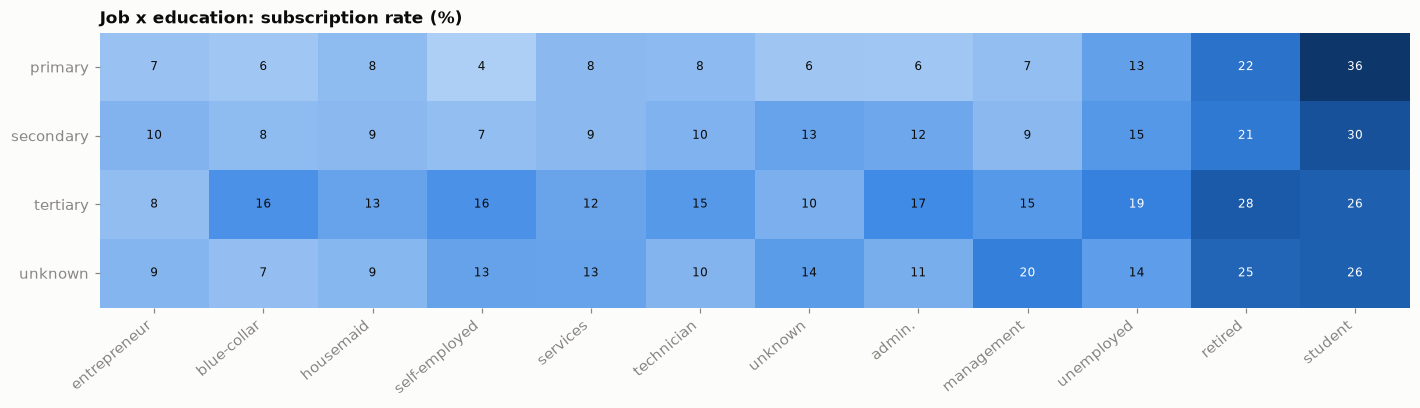

In [31]:
tab = df.pivot_table(index='education', columns='job', values='subscribed', aggfunc='mean') * 100
tab = tab.loc[['primary', 'secondary', 'tertiary', 'unknown'], tab.mean().sort_values().index]
fig, ax = plt.subplots(figsize=(13, 3.8))
heat(ax, tab, 'Job x education: subscription rate (%)')
plt.tight_layout()

Darker = higher subscription rate. Older age groups (60+) are high at every balance level; clients without any loan sit at 18% versus 6–8% elsewhere.

**Read small cells with care:** the 2008-10 (n=80) and 2009-03 (n=258) cells in the month x year chart are based on very few calls, which is why they stand out (61% and 48%). The same applies to the line chart in §1.

## G. Correlation structure (signed, so a diverging palette)

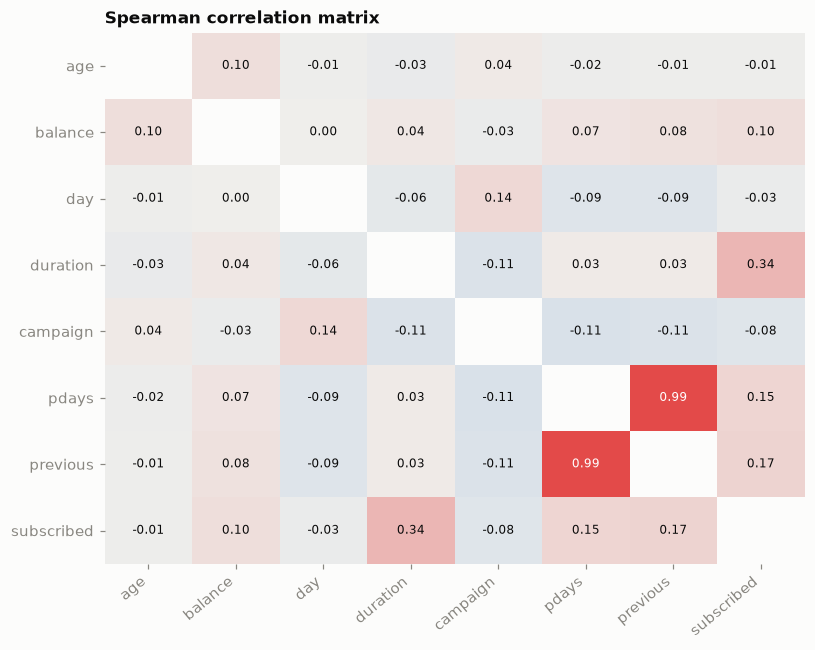

In [32]:
cn = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'subscribed']
corr = df[cn].corr(method='spearman')
corr = corr.mask(np.eye(len(cn), dtype=bool))   # the trivial 1.0s would dominate the colour scale
fig, ax = plt.subplots(figsize=(7.5, 6))
heat(ax, corr, 'Spearman correlation matrix', fmt='{:.2f}', vmax=1, cmap=DIV, center=0)
ax.set_xticklabels(cn, rotation=40, ha='right'); ax.set_yticklabels(cn)
plt.tight_layout()

Only `duration` (0.34) and the `pdays`/`previous` pair (0.99, same underlying 'never contacted' flag) stand out. Everything else is weak, which is why the non-linear patterns in §5–§9 above are easy to miss.

## H. Outcome mix and segment size (what drives the total subscribers?)

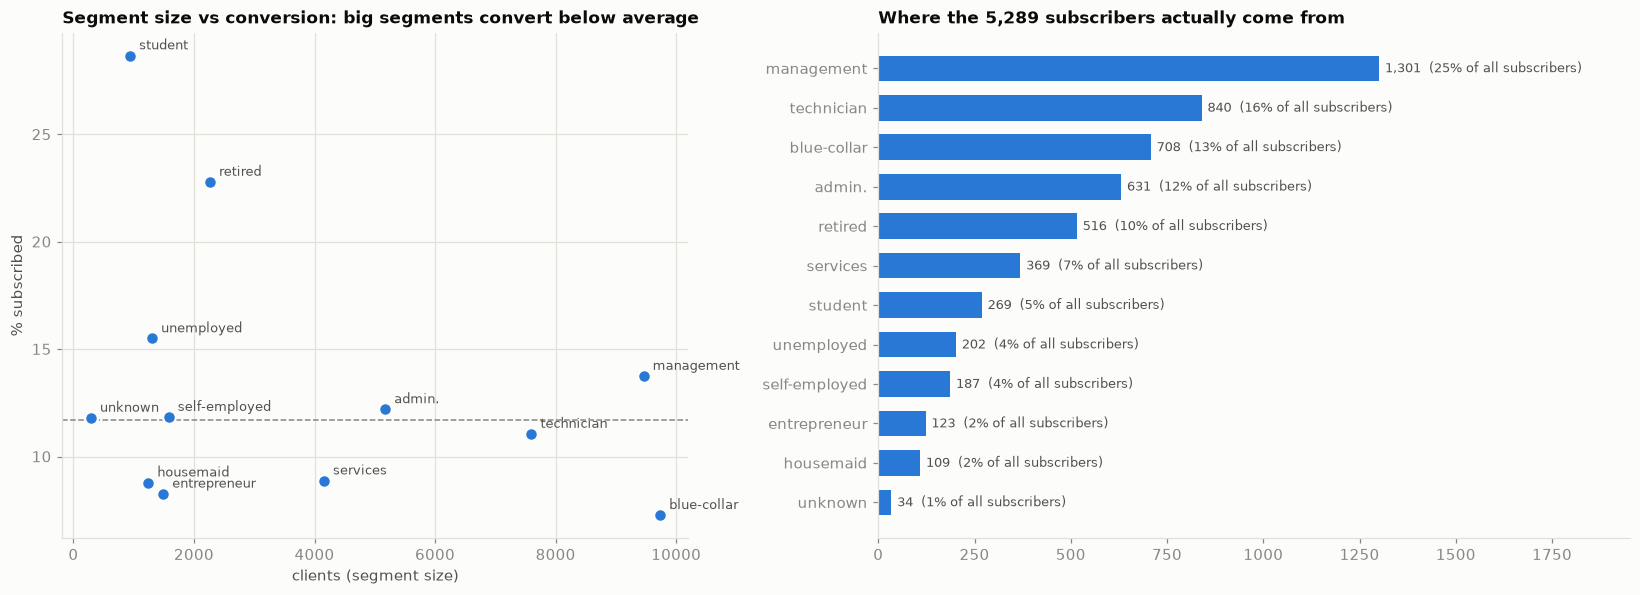

In [33]:
g = df.groupby('job').agg(n=('subscribed', 'size'), rate=('subscribed', 'mean'), subs=('subscribed', 'sum'))
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={'width_ratios': [1, 1.2]})
ax = axes[0]
ax.scatter(g.n, g.rate * 100, s=70, color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
for job, r in g.iterrows():
    ax.annotate(job, (r.n, r.rate * 100), xytext=(6, 4), textcoords='offset points', fontsize=8.5, color=INK2)
ax.axhline(overall, color=MUTED, ls='--', lw=1); ax.set_xlabel('clients (segment size)'); ax.set_ylabel('% subscribed')
ax.set_title('Segment size vs conversion: big segments convert below average')
s = g.subs.sort_values()
ax = axes[1]
ax.barh(s.index, s.values, color=BLUE, height=0.65); ax.grid(False)
for i, v in enumerate(s.values): ax.text(v + 15, i, f'{v:,}  ({v / g.subs.sum() * 100:.0f}% of all subscribers)', va='center', fontsize=8.5, color=INK2)
ax.set_xlim(0, s.max() * 1.5); ax.set_title('Where the 5,289 subscribers actually come from')
plt.tight_layout()

High-rate groups (students, retirees) are small, so most subscribers still come from the large management, technician, blue-collar and admin segments. Rate and volume tell different stories: target the high-rate groups for efficiency, the big segments for absolute numbers.

---
# Part 2: Statistical tests and predictive modelling

So far we have *described* the data. In this part we move to two harder questions:

1. **Are the differences we saw real, or could they be luck?** (statistical tests and a regression model)
2. **Can we predict who will subscribe *before* we call them?** (decision tree and other models)

### Roadmap
| Step | What we do | Plain-English purpose |
|---|---|---|
| 1 | Hypothesis tests | Check whether the patterns from Part 1 are bigger than random noise, and how big they are |
| 2 | Set up the prediction problem | Decide what the model may and may not look at, and hold back some data for an honest exam |
| 3 | Baseline | The score to beat: what a model that does nothing clever achieves |
| 4 | Decision tree | A model that learns a flowchart of yes/no questions. Easy to read and explain |
| 5 | Logistic regression | The classic statistical model. Tells us the *independent* effect of each factor |
| 6 | Compare models | ROC curves and a "lift" chart: how much better than guessing, and how much would it save us |
| 7 | What did the best model learn? | Which factors matter most and what shape their effect has |
| 8 | Time check | Does the model still work on *later* data? (Our data spans 3 years and the campaign changed) |

### Words used below
- **Subscribed (`y = yes`)**: the client signed up for the term deposit. This is what we want to predict.
- **Feature**: an input the model is allowed to use (age, job, and so on).
- **Training set / test set**: we teach the model on 70% of clients (training) and then grade it on the other 30% (test) that it has never seen. This is like studying from practice questions and then sitting a real exam; it stops us fooling ourselves.
- **Overfitting**: a model memorises quirks of the training data and does worse on new data.
- **p-value**: how surprising our result would be if there were truly *no* difference. Small (below 0.05) means "unlikely to be luck". With 45,000 rows almost everything is significant, so we also look at **effect size** (how big the difference is), which matters more.

In [34]:
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import warnings; warnings.filterwarnings('ignore')

RS = 42   # random seed, so the results are reproducible

## Step 1: Hypothesis tests. Are the patterns real, and how big are they?

**What we are doing.** In Part 1 we *saw* differences (for example, students subscribe more than blue-collar workers). A hypothesis test asks: *if job made no difference at all, how likely is it that we would see a gap this large just by chance?*

We use three standard tests:

- **Chi-square test** (for categories such as job vs subscribed). It compares the counts we observed with the counts we'd expect if the category were irrelevant. We also report **Cramér's V**, an effect-size score from 0 (no link) to 1 (perfect link). Rough guide: below 0.1 weak, 0.1–0.3 moderate, above 0.3 strong.
- **Mann–Whitney test** (for numbers such as age, comparing subscribers with non-subscribers). It doesn't assume a bell-shaped distribution, which suits our skewed variables. Its effect size is the **"probability of superiority"**: pick one random subscriber and one random non-subscriber; this is the chance the subscriber has the larger value. 50% means no difference.
- **Two-proportion z-test** (comparing two subscription rates directly, with a 95% confidence interval on the gap).

**How to read the results.** With 45,000 rows, even tiny differences get tiny p-values, so *do not stop at the p-value*. Look at the effect size column to see which differences are large enough to matter.

In [35]:
m = df.copy()
m['subscribed'] = (m.y == 'yes').astype(int)
m['age_group'] = pd.cut(m.age, [17, 29, 39, 49, 59, 100], labels=['<30', '30-39', '40-49', '50-59', '60+']).astype(str)

def cramers_v(a, b):
    t = pd.crosstab(a, b); chi2, p, dof, _ = stats.chi2_contingency(t)
    return chi2, dof, p, np.sqrt(chi2 / t.values.sum() / (min(t.shape) - 1))

rows = []
for c in ['poutcome', 'month', 'contact', 'housing', 'job', 'age_group', 'education', 'loan', 'marital', 'default']:
    chi2, dof, p, v = cramers_v(m[c], m.y)
    rows.append({'variable': c, 'chi-square': round(chi2), 'p-value': '<0.001' if p < 0.001 else f'{p:.3f}', "Cramér's V": round(v, 3),
                 'strength': 'strong' if v >= 0.3 else 'moderate' if v >= 0.1 else 'weak'})
print('CHI-SQUARE: is each category linked to subscribing?')
pd.DataFrame(rows).set_index('variable')

CHI-SQUARE: is each category linked to subscribing?


,chi-square,p-value,Cramér's V,strength
variable,,,,
poutcome,4392,<0.001,0.312,strong
month,3062,<0.001,0.260,moderate
contact,1036,<0.001,0.151,moderate
housing,875,<0.001,0.139,moderate
job,836,<0.001,0.136,moderate
age_group,1151,<0.001,0.160,moderate
education,239,<0.001,0.073,weak
loan,210,<0.001,0.068,weak
marital,196,<0.001,0.066,weak


In [36]:
rows = []
for c in ['age', 'balance', 'campaign', 'previous', 'duration']:
    a = m.loc[m.y == 'yes', c]; b = m.loc[m.y == 'no', c]
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    rows.append({'variable': c, 'median (subscribed)': a.median(), 'median (not)': b.median(),
                 'p-value': '<0.001' if p < 0.001 else f'{p:.3f}', 'P(subscriber > non-subscriber)': round(u / (len(a) * len(b)), 3)})
print('MANN-WHITNEY: do subscribers have higher or lower values?  (0.50 = no difference)')
pd.DataFrame(rows).set_index('variable')

MANN-WHITNEY: do subscribers have higher or lower values?  (0.50 = no difference)


,median (subscribed),median (not),p-value,P(subscriber > non-subscriber)
variable,,,,
age,38.0,39.0,0.063,0.492
balance,733.0,417.0,<0.001,0.590
campaign,2.0,2.0,<0.001,0.428
previous,0.0,0.0,<0.001,0.602
duration,426.0,164.0,<0.001,0.808


In [37]:
def two_prop(label, mask):
    g1, g2 = m[mask], m[~mask]
    k = np.array([g1.subscribed.sum(), g2.subscribed.sum()]); n = np.array([len(g1), len(g2)])
    z, p = proportions_ztest(k, n)
    lo, hi = confint_proportions_2indep(k[0], n[0], k[1], n[1])
    return {'comparison': label, 'rate group 1': f'{k[0]/n[0]:.1%}', 'rate group 2': f'{k[1]/n[1]:.1%}',
            'difference (pts)': f'{(k[0]/n[0]-k[1]/n[1])*100:+.1f}', '95% CI of diff (pts)': f'{lo*100:+.1f} to {hi*100:+.1f}',
            'p-value': '<0.001' if p < 0.001 else f'{p:.3f}'}

print('TWO-PROPORTION TESTS: group 1 vs group 2')
pd.DataFrame([
    two_prop('No housing loan AND no personal loan  vs  everyone else', (m.housing == 'no') & (m.loan == 'no')),
    two_prop('Age 60+  vs  under 60', m.age >= 60),
    two_prop('Previously subscribed (poutcome = success)  vs  others', m.poutcome == 'success'),
    two_prop('Cellular  vs  other contact types', m.contact == 'cellular'),
    two_prop('First call of the campaign  vs  repeat calls', m.campaign == 1),
]).set_index('comparison')

TWO-PROPORTION TESTS: group 1 vs group 2


,rate group 1,rate group 2,difference (pts),95% CI of diff (pts),p-value
comparison,,,,,
No housing loan AND no personal loan vs everyone else,18.2%,7.7%,+10.5,+9.9 to +11.2,<0.001
Age 60+ vs under 60,33.6%,10.8%,+22.8,+20.7 to +25.1,<0.001
Previously subscribed (poutcome = success) vs others,64.7%,9.9%,+54.9,+52.4 to +57.2,<0.001
Cellular vs other contact types,14.9%,5.8%,+9.1,+8.6 to +9.7,<0.001
First call of the campaign vs repeat calls,14.6%,9.9%,+4.7,+4.1 to +5.4,<0.001


### What the tests tell us
- **Every category is statistically linked to subscribing** (all p < 0.001), but the *strength* varies a lot. Prior campaign outcome (`poutcome`, V = 0.31) is the only strong link. Month (0.26), contact type, housing loan, job and **age group** (0.16) are moderate. Education, personal loan, marital status and default are weak: real but small.
- **A lesson about age.** The rank test says subscribers are *not* significantly older or younger than non-subscribers (p = 0.06, probability of superiority 0.49, essentially a coin flip), yet the age-group chi-square is clearly significant. That is the U-shape from Part 1: young and old clients both subscribe more, so the effects cancel when you just ask "are subscribers older?". A test that asks the wrong question can hide a real pattern.
- **Balance and previous contacts** are modestly higher for subscribers (0.59 and 0.60). Subscribers had *fewer* attempts this campaign (0.43).
- **`duration`** is the one strong numeric difference (0.81), but remember it is a *result* of the call, not something we can know in advance.
- **Two-proportion tests:** the gaps are large and their confidence intervals are tight: debt-free clients **+10.5 points**, age 60+ **+22.8**, prior success **+54.9**, cellular contact **+9.1**, first call **+4.7**. None of these intervals comes near zero. But the next table shows these pooled gaps need careful reading.

### A robustness check: does each pattern hold in every year?
Because the campaign changed so much between 2008 and 2010, a pattern could be an illusion caused by *when* clients were called (a statistical trap called **Simpson's paradox**: a trend that appears in the combined data but vanishes or reverses inside each group). So we repeat two key comparisons separately for each year. If the gap points the same way each year, we can trust it more.

In [38]:
chk, shift = [], []
for yr, g in m.groupby('year'):
    old, loans0 = g.age >= 60, (g.housing == 'no') & (g.loan == 'no')
    chk.append({'year': yr, 'calls': len(g), 'n aged 60+': int(old.sum()),
                'age 60+': g[old].subscribed.mean() * 100, 'age < 60': g[~old].subscribed.mean() * 100,
                'no loans': g[loans0].subscribed.mean() * 100, 'has a loan': g[~loans0].subscribed.mean() * 100,
                'first call': g[g.campaign == 1].subscribed.mean() * 100, 'repeat calls': g[g.campaign > 1].subscribed.mean() * 100})
    shift.append({'year': yr, 'share of calls aged 60+': old.mean() * 100, 'share with no loans': loans0.mean() * 100,
                  'share first-call': (g.campaign == 1).mean() * 100, 'share cellular': (g.contact == 'cellular').mean() * 100,
                  'share with prior contact': (g.poutcome != 'unknown').mean() * 100})
print('Subscription rate (%) within each year')
display(pd.DataFrame(chk).set_index('year').round(1))
print("Who was being called each year (% of that year's calls)")
display(pd.DataFrame(shift).set_index('year').round(1))

Subscription rate (%) within each year


,calls,n aged 60+,age 60+,age < 60,no loans,has a loan,first call,repeat calls
year,,,,,,,,
2008,27729,410,5.6,5.0,5.5,4.8,5.3,4.9
2009,14862,857,35.9,15.9,28.8,10.5,19.0,15.3
2010,2620,517,52.0,51.5,52.7,48.2,51.9,51.3


Who was being called each year (% of that year's calls)


,share of calls aged 60+,share with no loans,share first-call,share cellular,share with prior contact
year,,,,,
2008,1.5,35.6,32.6,49.1,3.3
2009,5.8,35.9,47.6,91.2,37.8
2010,19.7,76.2,54.6,80.2,65.6


### What the robustness check reveals (an important correction to Part 1)
The gaps are **not constant across years**:

| Pattern | 2008 | 2009 | 2010 |
|---|---|---|---|
| Age 60+ vs under 60 | 5.6% vs 5.0% (no gap) | **35.9% vs 15.9%** | 52.0% vs 51.5% (no gap) |
| No loans vs has a loan | 5.5% vs 4.8% | **28.8% vs 10.5%** | 52.7% vs 48.2% |
| First call vs repeat | 5.3% vs 4.9% | **19.0% vs 15.3%** | 51.9% vs 51.3% |

The second table explains why. **The bank changed *whom* it called.** Clients aged 60+ went from 1.5% of calls (2008) to 19.7% (2010); debt-free clients from 36% to 76%; clients with a prior contact from 3% to 66%. In 2008 almost everyone was called indiscriminately, so the success rate was stuck near 5% whatever the client looked like. By 2010 the bank was calling a pre-screened, warm list, so success was around 52% for everyone and the characteristics no longer separated people. The real differences show up in **2009**, the transition year.

**What this means:** the age and debt effects in Part 1 are real *within* the middle period, but the pooled numbers were inflated because the years with more older/debt-free clients also had much higher success rates for other reasons (a statistical trap called **confounding**). From here on we therefore always compare models *with* and *without* timing information, and the regression below controls for the year.

## Step 2: Set up the prediction problem

**The question:** *Given what we know about a client before we pick up the phone, how likely are they to subscribe?*

This is useful in practice: if we can rank clients by likelihood, the bank can call the most promising ones first and spend less time on the rest.

### Rule 1: only use information available *before* the call
- **`duration` is excluded.** The length of a call is only known once the call is over, and long calls are mostly a *result* of the client being interested. Including it would make the model look brilliant (AUC about 0.94) but it would be useless for deciding whom to call. This is called **data leakage**.
- `pdays` is dropped: it is 99% duplicated by `previous` (both just flag "contacted before").
- Skewed numbers are handled sensibly: balance is log-scaled for the regression model (trees don't need this), attempts are capped at 15 and previous contacts at 10 so a handful of extreme rows can't dominate.

### Rule 2: two versions of every model
Part 1 showed that *when* a client was called matters a lot (the campaign got better targeted over time). So we build each model twice:

- **Model A, "client-only":** who the client is, their history with the bank, and how many times we've tried. *This is the model we'd use to choose who to call.*
- **Model B, "client + timing":** Model A plus `contact` type, `month`, `day` and the (inferred) `year`. These describe *how the campaign was running*, not the client. Comparing A and B shows how much of the predictive power is really just campaign timing.

### Rule 3: grade the model on data it has never seen
We randomly set aside 30% of clients as a **test set**, keeping the same 11.7% subscribe rate in both parts (a *stratified* split). All learning happens on the 70% training set.

In [39]:
# --- transformed copies of numeric columns (used by the regression model; trees use the raw ones) ---
m['balance_slog'] = np.sign(m.balance) * np.log10(1 + m.balance.abs())   # signed log: keeps negatives, tames the huge values
m['campaign_c'] = m.campaign.clip(upper=15)
m['previous_c'] = m.previous.clip(upper=10)
m['year'] = m.year.astype(str)

A_CAT = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'poutcome']     # who they are + history
A_NUM = ['age', 'balance', 'campaign', 'previous']
T_CAT = ['contact', 'month', 'year']                                                   # campaign timing (Model B only)

idx_train, idx_test = train_test_split(m.index, test_size=0.30, stratify=m.subscribed, random_state=RS)
y_train, y_test = m.loc[idx_train, 'subscribed'], m.loc[idx_test, 'subscribed']
print(f'training clients: {len(idx_train):,} (subscribe rate {y_train.mean():.1%})')
print(f'test clients:     {len(idx_test):,} (subscribe rate {y_test.mean():.1%})')

training clients: 31,647 (subscribe rate 11.7%)
test clients:     13,564 (subscribe rate 11.7%)


### How we will score the models
- **AUC (area under the ROC curve).** Pick one client who subscribed and one who didn't. AUC is the chance that the model gave the subscriber the *higher* score. **0.5 = coin flip, 1.0 = perfect.** It is about *ranking*, which is what we need to decide whom to call first. Rule of thumb: 0.6–0.7 poor, 0.7–0.8 decent, 0.8–0.9 good.
- **Average precision (AP).** Another ranking score that cares more about getting the *top* of the list right. The "do nothing" level is just the subscribe rate (11.7%), so higher is better.
- **Lift / gains.** "If we only call the top 20% of clients ranked by the model, what share of all subscribers do we reach?" This translates the model into business terms.

## Step 3: The baseline. What does "doing nothing clever" score?

Before building anything, we need a score to beat. The laziest model predicts **"no" for everybody**. Because 88% of clients say no, it is "right" 88% of the time while being completely useless (it never finds a single subscriber). This is why we don't use plain *accuracy* here: the classes are very imbalanced, so we use AUC, which is not fooled by this.

In [40]:
print(f'"Everyone says no" accuracy on test set: {1 - y_test.mean():.1%}   (but it finds 0 of {y_test.sum():,} subscribers)')
print(f'"Everyone says no" AUC: 0.500   (no ability to rank clients)')
print(f'Average-precision baseline = the subscribe rate = {y_test.mean():.3f}')

"Everyone says no" accuracy on test set: 88.3%   (but it finds 0 of 1,587 subscribers)
"Everyone says no" AUC: 0.500   (no ability to rank clients)
Average-precision baseline = the subscribe rate = 0.117


## Step 4: The decision tree

**What it is.** A decision tree is a flowchart. At each step it asks a yes/no question about one feature (for example *"did this client subscribe in a previous campaign?"*), sends the client down the "yes" or "no" branch, and repeats. At the end of each branch (a **leaf**) it reports the share of similar clients who subscribed. That share is the model's predicted probability for anyone landing there.

**How it learns.** The tree tries every possible question and picks the one that best *separates* subscribers from non-subscribers, then repeats inside each branch. Left unchecked it keeps splitting until it has memorised the training data (overfitting). So we limit how deep it can grow.

### 4a. A small tree you can read
We first grow a deliberately small tree (3 questions deep) so the whole flowchart fits on one page.

**How to read the picture:** each box shows the question, the number of clients (`samples`), and the share who said no/yes (`value = [no, yes]`). **Orange boxes = mostly "no", blue boxes = mostly "yes"**; the darker the colour, the more one-sided. For the question in a box, go **left if the answer is True, right if False**.

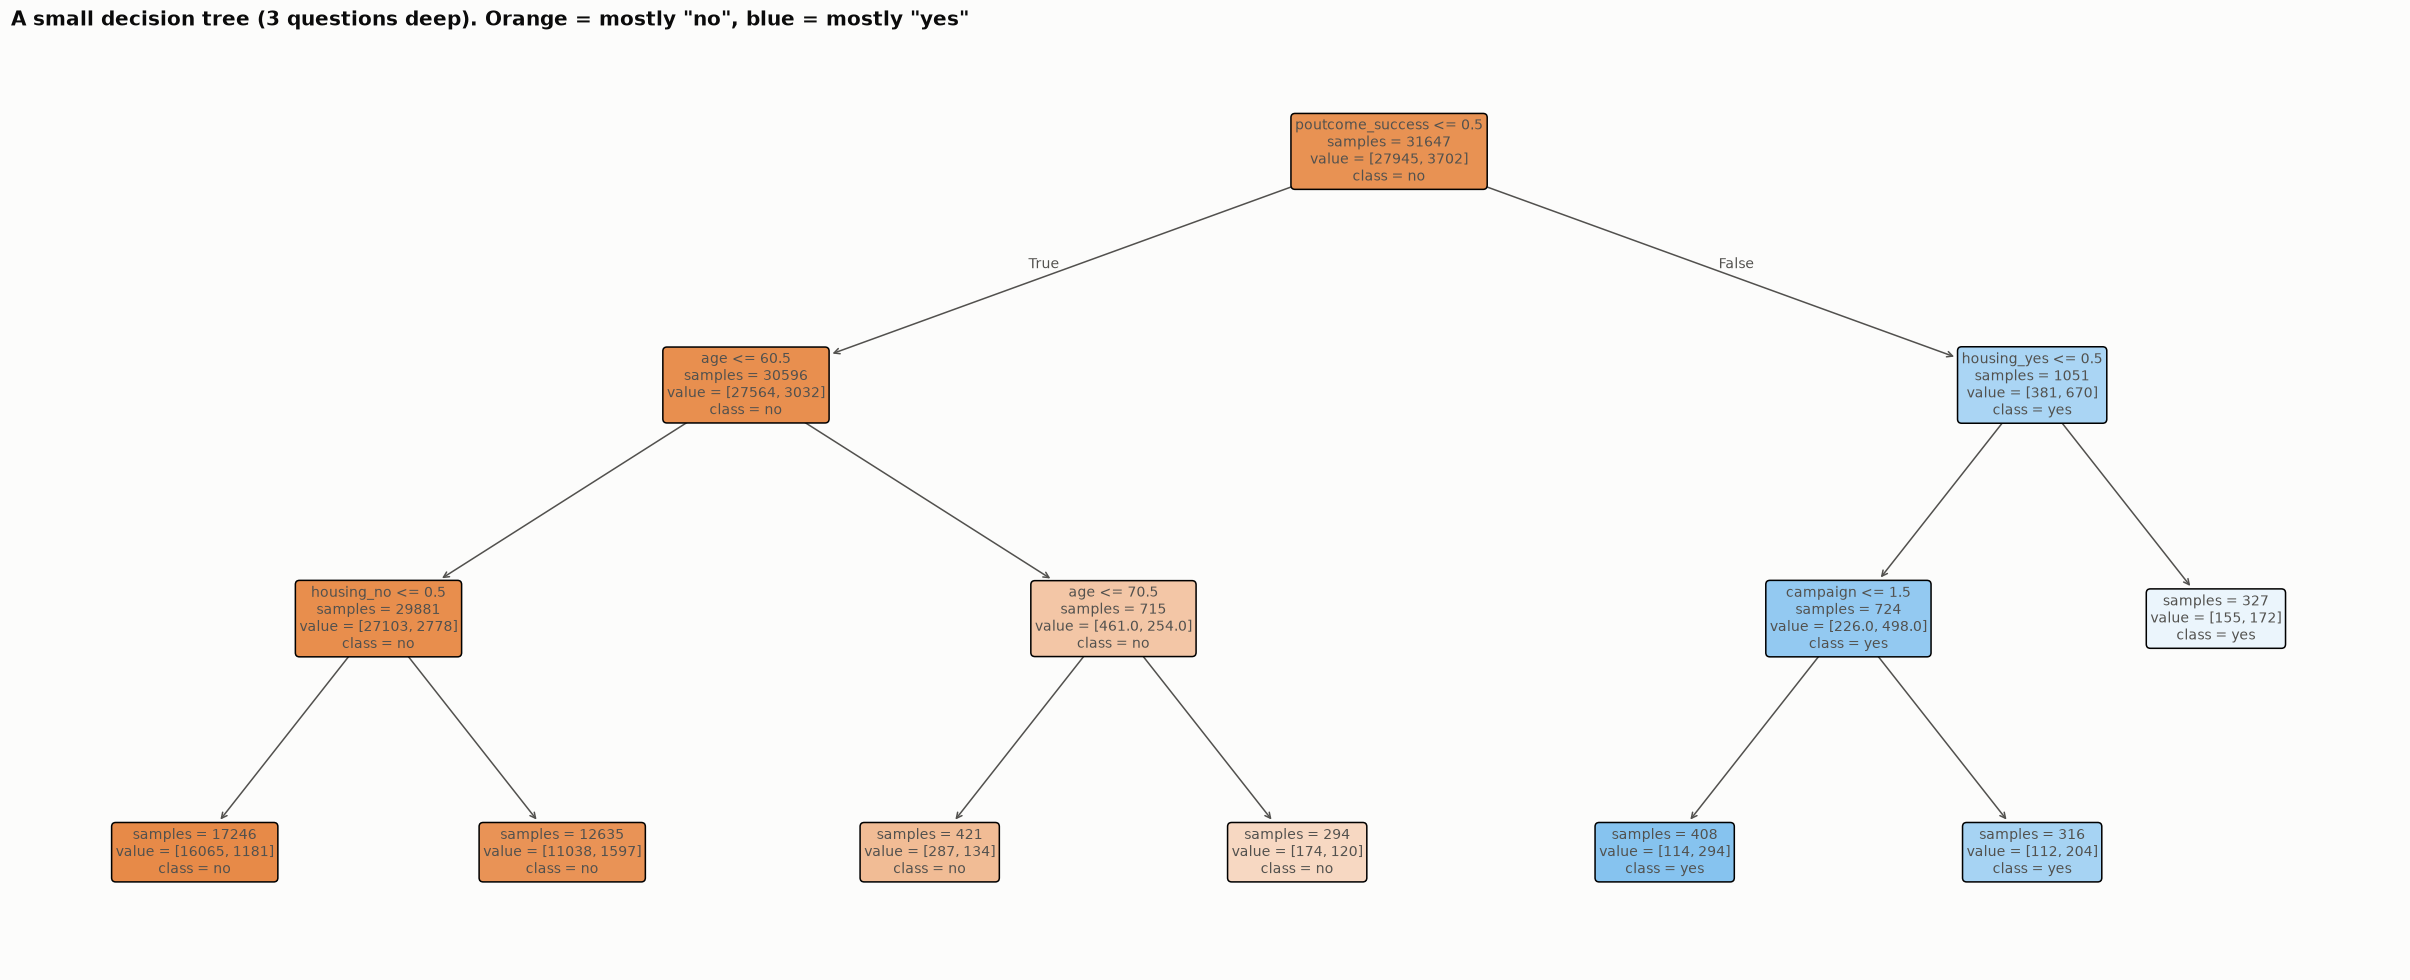

In [41]:
# Trees do not need log-scaling, so use the raw numbers; categories become 0/1 columns (one per category).
def tree_prep(cat, num):
    return ColumnTransformer([('n', 'passthrough', num), ('c', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat)],
                             verbose_feature_names_out=False)

prepA = tree_prep(A_CAT, A_NUM)
Xtr_arr = prepA.fit_transform(m.loc[idx_train, A_NUM + A_CAT]); Xte_arr = prepA.transform(m.loc[idx_test, A_NUM + A_CAT])
feat_names = list(prepA.get_feature_names_out())

small = DecisionTreeClassifier(max_depth=3, min_samples_leaf=200, random_state=RS).fit(Xtr_arr, y_train)
fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(small, feature_names=feat_names, class_names=['no', 'yes'], filled=True, rounded=True, impurity=False,
          proportion=False, fontsize=9, ax=ax)
ax.set_title('A small decision tree (3 questions deep). Orange = mostly "no", blue = mostly "yes"', fontsize=13, loc='left')
plt.tight_layout()

### 4b. The same tree as plain-English segments
A tree is really a set of rules: each leaf is a *segment* of clients defined by the answers along its path. The table lists every segment with how many clients fall into it and what share subscribed, in the training data (where the tree learned) and in the **test data** (which the tree never saw). If the two columns agree, the rule generalises; if they differ a lot, it was luck.

In [42]:
import math
ONEHOT = set(n for n in feat_names if n not in A_NUM)

def leaf_table(tree, names, Xtr, ytr, Xte, yte):
    t = tree.tree_; rules = {}
    def describe(path):
        cats, num = [], {}
        for f, went_right, thr in path:
            if f in ONEHOT:
                var, lev = f.split('_', 1)
                if lev in ('yes', 'no') and var in ('housing', 'loan', 'default'): cats.append(f'{var} = {lev}' if went_right else f'{var} = {"no" if lev == "yes" else "yes"}')
                else: cats.append(f'{var} is {lev}' if went_right else f'{var} is not {lev}')
            else:
                lo, hi = num.get(f, (-np.inf, np.inf))
                num[f] = (max(lo, math.floor(thr)), hi) if went_right else (lo, min(hi, math.floor(thr)))
        for f, (lo, hi) in num.items():
            cats.append(f'{f} between {lo + 1} and {hi}' if np.isfinite(lo) and np.isfinite(hi) else f'{f} >= {lo + 1}' if np.isfinite(lo) else f'{f} <= {hi}')
        return ' AND '.join(cats) if cats else '(everyone)'
    def walk(node, path):
        if t.children_left[node] == -1:
            rules[node] = describe(path); return
        f, thr = names[t.feature[node]], t.threshold[node]
        walk(t.children_left[node], path + [(f, False, thr)]); walk(t.children_right[node], path + [(f, True, thr)])
    walk(0, [])
    ltr, lte = tree.apply(Xtr), tree.apply(Xte)
    out = []
    for leaf, rule in rules.items():
        a, b = ytr[ltr == leaf], yte[lte == leaf]
        out.append({'segment (rule)': rule, 'train clients': len(a), 'train % subscribed': a.mean() * 100,
                    'test clients': len(b), 'test % subscribed': b.mean() * 100 if len(b) else np.nan})
    return pd.DataFrame(out).sort_values('train % subscribed', ascending=False).reset_index(drop=True)

pd.set_option('display.max_colwidth', None)

leaf_table(small, feat_names, Xtr_arr, y_train.values, Xte_arr, y_test.values).round(1)

,segment (rule),train clients,train % subscribed,test clients,test % subscribed
0,poutcome is success AND housing = no AND campaign <= 1,408,72.1,166,69.3
1,poutcome is success AND housing = no AND campaign >= 2,316,64.6,150,77.3
2,poutcome is success AND housing = yes,327,52.6,144,53.5
3,poutcome is not success AND age >= 71,294,40.8,112,35.7
4,poutcome is not success AND age between 61 and 70,421,31.8,162,39.5
5,poutcome is not success AND housing = no AND age <= 60,12635,12.6,5482,12.7
6,poutcome is not success AND housing = yes AND age <= 60,17246,6.8,7348,6.5


### What the small tree found
Just three questions produce seven segments, and **training and test percentages agree closely**, so these rules are not luck:

1. **Previously subscribed (`poutcome = success`) and no housing loan: 72% (test 69–77%).** These are the most promising clients by far.
2. Previously subscribed *with* a housing loan: still 53%.
3. **No prior success, but older than 60:** 41% (age 71+) and 32–40% (age 61–70).
4. Everyone else (the large majority, about 30,000 clients under 60 with no prior success): **12.6% if they have no housing loan vs 6.8% if they do**.

So the tree's priorities are: *prior success first, then age 60+, then the housing loan*. Notice the tree splits age at exactly 60 and again at 70. That is a sharp cliff, not a gentle slope, which hints at how the bank selected people to call.

### 4c. Choosing how deep the tree should grow (guarding against overfitting)
A deeper tree can ask more questions and fit more detail, but eventually it starts memorising noise. We want the depth where performance on *unseen* data peaks.

**How:** for each depth from 1 to 14 we measure AUC two ways:
- on the **training data** it learned from (always keeps improving as the tree grows, so this alone is misleading), and
- using **5-fold cross-validation**: split the training set into 5 parts, train on 4, score on the 5th, rotate, and average. This estimates how the tree does on data it hasn't seen, *without touching the test set*.

When the two lines drift apart the tree is overfitting. We pick the **simplest tree whose cross-validated AUC is within 0.005 of the best**, because a simpler tree is easier to explain and more likely to hold up.

Best cross-validated AUC 0.716; simplest tree within 0.005 of that has depth 6


,train_auc,cv_auc,cv_sd
depth,,,
1,0.584,0.584,0.011
2,0.611,0.611,0.013
3,0.672,0.672,0.019
4,0.693,0.693,0.020
5,0.708,0.701,0.021
6,0.727,0.713,0.021
7,0.738,0.716,0.017
8,0.748,0.716,0.019
9,0.759,0.714,0.019


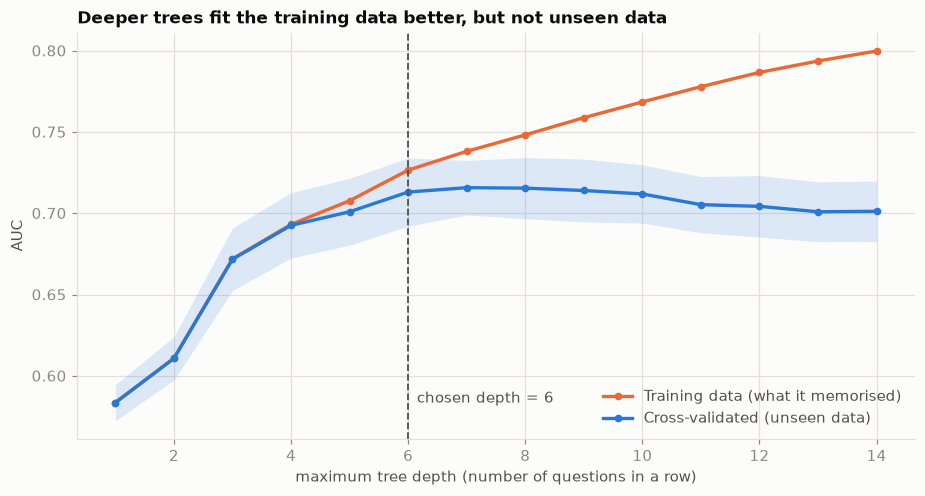

In [43]:
cv5 = StratifiedKFold(5, shuffle=True, random_state=RS)
curve = []
for d in range(1, 15):
    pipe = Pipeline([('prep', tree_prep(A_CAT, A_NUM)), ('m', DecisionTreeClassifier(max_depth=d, min_samples_leaf=50, random_state=RS))])
    r = cross_validate(pipe, m.loc[idx_train, A_NUM + A_CAT], y_train, cv=cv5, scoring='roc_auc', return_train_score=True)
    curve.append({'depth': d, 'train_auc': r['train_score'].mean(), 'cv_auc': r['test_score'].mean(), 'cv_sd': r['test_score'].std()})
curve = pd.DataFrame(curve).set_index('depth')
best = curve.cv_auc.max()
TREE_DEPTH = int(curve[curve.cv_auc >= best - 0.005].index.min())

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(curve.index, curve.train_auc, color=ORANGE, lw=2.2, marker='o', ms=4, label='Training data (what it memorised)')
ax.plot(curve.index, curve.cv_auc, color=BLUE, lw=2.2, marker='o', ms=4, label='Cross-validated (unseen data)')
ax.fill_between(curve.index, curve.cv_auc - curve.cv_sd, curve.cv_auc + curve.cv_sd, color=BLUE, alpha=0.15, lw=0)
ax.axvline(TREE_DEPTH, color=INK2, ls='--', lw=1.2); ax.text(TREE_DEPTH + 0.15, curve.cv_auc.min(), f'chosen depth = {TREE_DEPTH}', color=INK2)
ax.set_xlabel('maximum tree depth (number of questions in a row)'); ax.set_ylabel('AUC'); ax.legend(frameon=False, loc='lower right')
ax.set_title('Deeper trees fit the training data better, but not unseen data')
plt.tight_layout()
print(f'Best cross-validated AUC {best:.3f}; simplest tree within 0.005 of that has depth {TREE_DEPTH}')
curve.round(3)

### How deep should the tree be?
The orange line shows what we feared: the more questions we allow, the better the tree fits the *training* data (AUC climbs from 0.58 to 0.80). The blue line, which measures performance on data the tree hasn't seen, **peaks around depth 7–8 (AUC about 0.716) and then declines**. The gap between the lines at large depths is the overfitting. Depth 6 is within 0.005 of the best, so by our rule we take it. The shaded band (one standard deviation across the 5 folds) shows that differences between depths 6–9 are within noise, so there is no point agonising over the exact value.

## Step 5: Logistic regression. The independent effect of each factor

**What it is.** The workhorse of statistical modelling for yes/no outcomes. It estimates how each factor changes the **odds** of subscribing *while holding all the other factors fixed*. This is the key difference from the simple tables in Part 1 (which look at one factor at a time and so can mix up cause and coincidence; for example, retirees are older *and* richer, so which one matters?).

**How to read an odds ratio (OR):**
- **OR = 1** → no effect.
- **OR = 2** → the odds of subscribing are *double* those of the reference group.
- **OR = 0.5** → the odds are *halved*.
- Each OR comes with a **95% confidence interval (CI)**. If the interval *excludes 1*, the effect is statistically significant. A wide interval means we're unsure how big the effect is.

Every category is compared with a **reference group** (e.g. job is compared with "blue-collar", age with "40-49"), named in the table.

**Two models again:** we fit Model A (client only) and Model B (adds contact type, month and year). Comparing the two tells us *which client effects survive once we account for campaign timing*. For this explanatory step we use all 45,211 clients, because we are measuring effects, not predicting.

In [44]:
base = ("subscribed ~ C(age_group, Treatment(reference='40-49')) + balance_slog + campaign_c + previous_c"
        " + C(job, Treatment(reference='blue-collar')) + C(marital, Treatment(reference='married'))"
        " + C(education, Treatment(reference='secondary')) + C(default, Treatment(reference='no'))"
        " + C(housing, Treatment(reference='no')) + C(loan, Treatment(reference='no'))"
        " + C(poutcome, Treatment(reference='unknown'))")
timing = " + C(contact, Treatment(reference='cellular')) + C(year, Treatment(reference='2009')) + C(month, Treatment(reference='may'))"
logitA = smf.logit(base, m).fit(disp=0, maxiter=200)
logitB = smf.logit(base + timing, m).fit(disp=0, maxiter=200)

import re
def pretty(name):
    mt = re.match(r"C\((\w+), Treatment\(reference='([^']+)'\)\)\[T\.(.+)\]", name)
    return f'{mt.group(1)}: {mt.group(3)}  (vs {mt.group(2)})' if mt else name

def or_table(res):
    ci = np.exp(res.conf_int())
    t = pd.DataFrame({'odds ratio': np.exp(res.params), 'ci_low': ci[0], 'ci_high': ci[1], 'p': res.pvalues})
    t.index = [pretty(i) for i in t.index]
    return t.drop('Intercept')

orA, orB = or_table(logitA), or_table(logitB)

# How well does each model fit, and is adding timing worth it?  (likelihood-ratio test)
lr_stat = 2 * (logitB.llf - logitA.llf); dfd = logitB.df_model - logitA.df_model
fit = pd.DataFrame({'Model A (client only)': [logitA.nobs, logitA.llf, logitA.aic, logitA.bic, logitA.prsquared],
                    'Model B (+ timing)': [logitB.nobs, logitB.llf, logitB.aic, logitB.bic, logitB.prsquared]},
                   index=['clients', 'log-likelihood', 'AIC (lower = better)', 'BIC (lower = better)', 'pseudo R-squared'])
print(f'Likelihood-ratio test, does adding timing improve the fit? chi-square = {lr_stat:,.0f} on {int(dfd)} df, p = {stats.chi2.sf(lr_stat, dfd):.2g}')
fit.round(3)

Likelihood-ratio test, does adding timing improve the fit? chi-square = 2,215 on 15 df, p = 0


,Model A (client only),Model B (+ timing)
clients,45211.000,45211.000
log-likelihood,-14076.419,-12968.968
AIC (lower = better),28212.839,26027.936
BIC (lower = better),28474.412,26420.295
pseudo R-squared,0.137,0.205


### How good is the regression model, and does timing matter?
- Adding contact type, month and year improves the fit substantially: the likelihood-ratio test gives chi-square = 2,215 on 15 degrees of freedom (p is effectively zero), AIC drops from 28,213 to 26,028 and pseudo R-squared goes from 0.137 to 0.205. In plain words: **timing information explains a large chunk of the outcome that client characteristics alone can't.**
- Pseudo R-squared values of 0.14–0.21 are typical for human-behaviour data. They mean there is real signal but a lot of unexplained randomness; no model will predict individual clients with certainty.

### Odds ratios, Model A vs Model B
Each row is one factor. The **dot** is the estimated odds ratio and the **line** is its 95% confidence interval. The x-axis is logarithmic (so "double" and "half" sit the same distance from 1). **Blue = Model A** (client only), **orange = Model B** (after also accounting for campaign timing). The vertical dashed line at 1 means "no effect": a dot far from the line with a CI that doesn't touch it is a real effect. If the orange dot sits far from the blue one, accounting for timing changed the story for that factor.

,A: odds ratio,A: ci_low,A: ci_high,A: p,B: odds ratio,B: ci_low,B: ci_high,B: p
age_group: 30-39 (vs 40-49),1.06,0.97,1.16,0.18,0.97,0.88,1.06,0.45
age_group: 50-59 (vs 40-49),0.93,0.84,1.03,0.16,0.95,0.86,1.06,0.40
age_group: 60+ (vs 40-49),2.74,2.33,3.23,0.00,1.43,1.19,1.71,0.00
age_group: <30 (vs 40-49),1.59,1.42,1.79,0.00,1.19,1.05,1.34,0.01
job: admin. (vs blue-collar),1.25,1.10,1.42,0.00,1.03,0.90,1.17,0.69
job: entrepreneur (vs blue-collar),0.95,0.76,1.17,0.61,0.95,0.76,1.19,0.66
job: housemaid (vs blue-collar),0.83,0.66,1.04,0.10,0.79,0.63,1.01,0.06
job: management (vs blue-collar),1.16,1.02,1.32,0.02,1.07,0.94,1.23,0.29
job: retired (vs blue-collar),1.26,1.06,1.50,0.01,1.10,0.92,1.33,0.30
job: self-employed (vs blue-collar),1.02,0.84,1.24,0.84,1.00,0.82,1.22,0.99


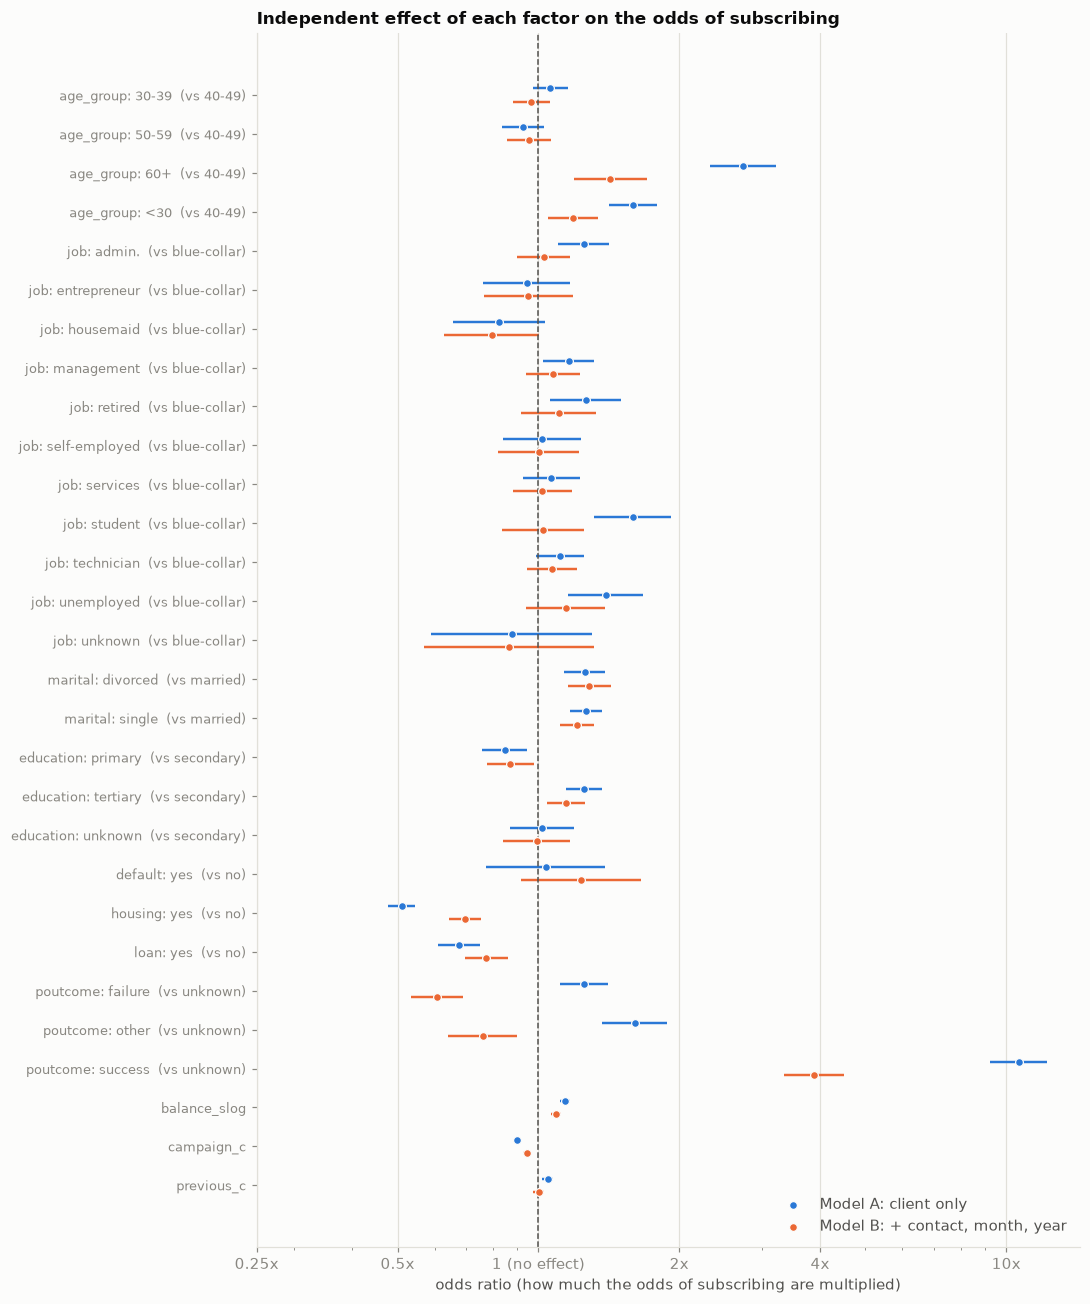

In [45]:
terms = [t for t in orA.index]
fig, ax = plt.subplots(figsize=(10, 0.36 * len(terms) + 1.5))
ypos = np.arange(len(terms))[::-1]
for off, tbl, col, lab in [(0.17, orA, BLUE, 'Model A: client only'), (-0.17, orB, ORANGE, 'Model B: + contact, month, year')]:
    t = tbl.loc[terms]
    ax.hlines(ypos + off, t.ci_low, t.ci_high, color=col, lw=1.6)
    ax.scatter(t['odds ratio'], ypos + off, color=col, s=26, zorder=3, edgecolor=SURFACE, linewidth=0.8, label=lab)
ax.axvline(1, color=INK2, ls='--', lw=1); ax.set_xscale('log')
ax.set_xticks([0.25, 0.5, 1, 2, 4, 10]); ax.set_xticklabels(['0.25x', '0.5x', '1 (no effect)', '2x', '4x', '10x'])
ax.set_yticks(ypos); ax.set_yticklabels(terms, fontsize=8.5); ax.grid(axis='y', visible=False)
ax.set_xlabel('odds ratio (how much the odds of subscribing are multiplied)'); ax.legend(frameon=False, loc='lower right')
ax.set_title('Independent effect of each factor on the odds of subscribing')
plt.tight_layout()
pd.concat([orA.add_prefix('A: '), orB.loc[terms].add_prefix('B: ')], axis=1).round(2)[['A: odds ratio', 'A: ci_low', 'A: ci_high', 'A: p', 'B: odds ratio', 'B: ci_low', 'B: ci_high', 'B: p']]

### Reading the odds-ratio chart (the key result of the regression)
Compare the **blue dots (Model A)** with the **orange dots (Model B)**; the gap shows how much of each effect was really a timing effect.

**Effects that shrink a lot once timing is accounted for:**
- **Prior success** (`poutcome = success`): from **10.6× to 3.9×** the odds. Still by far the biggest effect, but much smaller than the raw numbers suggested.
- **Age 60+**: from 2.7× to **1.4×**; under 30 from 1.6× to 1.2×.
- **Student** (1.6× → 1.0×), **retired** (1.3× → 1.1×), **unemployed** and **admin** lose significance entirely. Their apparent advantage was mostly a matter of *when and how* they were called.

**Effects that hold up:**
- **Housing loan**: odds about 30% lower (OR 0.70) and **personal loan** about 23% lower (0.77), both clearly significant.
- **Single and divorced** clients: about 1.2–1.3× versus married. **Tertiary education**: 1.15× vs secondary (primary 0.87×).
- **More attempts in this campaign**: each extra call multiplies the odds by 0.95 (0.90 before accounting for timing).
- **Balance**: each tenfold increase in balance multiplies the odds by about 1.09.

**One reversal:** prior *failure* looks like a good sign in Model A (1.25×) but becomes a *bad* sign (0.61×) once timing is controlled: clients who turned us down before are less likely than first-time contacts called in the same period. The raw pattern was an artefact of those clients being called later, when everything converted better.

**Caveat:** a regression shows *associations*, not causes, and it assumes each effect is the same in every year. The robustness table showed that's only roughly true, so treat the sizes as averages.

## Step 6: Build the prediction models and compare them

We now train three kinds of model on the training set and grade them on the test set, each in version A (client only) and version B (+ timing):

| Model | How it works | Strength | Weakness |
|---|---|---|---|
| **Logistic regression** | Adds up weighted evidence from each factor | Simple, stable, explainable | Assumes each factor acts in a straight-line way |
| **Decision tree** | One flowchart of yes/no questions (depth chosen in 4c) | Very easy to explain | Single trees are unstable and fairly crude |
| **Gradient boosting** | Builds hundreds of small trees, each one correcting the mistakes of the previous ones | Usually the most accurate; captures curves and interactions | A black box: harder to explain |

Gradient boosting is included as a **benchmark**: if the simple, explainable models come close to it, we don't need the complicated one.

In [46]:
def build_models(timing):
    cat = A_CAT + (T_CAT if timing else [])
    raw = A_NUM + (['day'] if timing else [])
    lrnum = ['age', 'balance_slog', 'campaign_c', 'previous_c'] + (['day'] if timing else [])
    ohe = lambda: OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    lr = Pipeline([('prep', ColumnTransformer([('n', StandardScaler(), lrnum), ('c', ohe(), cat)])),
                   ('m', LogisticRegression(max_iter=3000))])
    tr = Pipeline([('prep', tree_prep(cat, raw)), ('m', DecisionTreeClassifier(max_depth=TREE_DEPTH, min_samples_leaf=50, random_state=RS))])
    gb = Pipeline([('prep', ColumnTransformer([('c', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat)], remainder='passthrough')),
                   ('m', HistGradientBoostingClassifier(categorical_features=list(range(len(cat))), learning_rate=0.05, max_iter=300, max_depth=4,
                                                        l2_regularization=1.0, early_stopping=True, random_state=RS))])
    return {'Logistic regression': (lr, lrnum + cat), 'Decision tree': (tr, raw + cat), 'Gradient boosting': (gb, cat + raw)}

def fit_all(timing, tr_idx, te_idx):
    out = {}
    for name, (pipe, cols) in build_models(timing).items():
        pipe.fit(m.loc[tr_idx, cols], m.loc[tr_idx, 'subscribed'])
        out[name] = dict(pipe=pipe, cols=cols, score=pipe.predict_proba(m.loc[te_idx, cols])[:, 1])
    return out

fits = {'A': fit_all(False, idx_train, idx_test), 'B': fit_all(True, idx_train, idx_test)}
res = []
for v, label in [('A', 'A: client only'), ('B', 'B: + timing')]:
    for name, f in fits[v].items():
        res.append({'version': label, 'model': name, 'AUC': roc_auc_score(y_test, f['score']), 'avg precision': average_precision_score(y_test, f['score'])})
results = pd.DataFrame(res)
print(f'Test-set scores (baseline: AUC 0.500, average precision {y_test.mean():.3f})')
results.pivot(index='model', columns='version', values=['AUC', 'avg precision']).round(3)

Test-set scores (baseline: AUC 0.500, average precision 0.117)


AUC              avg precision            
version             A: client only B: + timing A: client only B: + timing
model                                                                    
Decision tree                0.720       0.783          0.347       0.428
Gradient boosting            0.742       0.810          0.384       0.489
Logistic regression          0.735       0.797          0.370       0.463

### How do the models compare?
- **Model A (client only): AUC 0.72–0.74.** That is "decent": it correctly ranks a random subscriber above a random non-subscriber about 74% of the time (50% would be guessing). Average precision is about 0.37 against a baseline of 0.117, roughly **3× better than chance** at the top of the list.
- **Gradient boosting (0.742) is barely better than simple logistic regression (0.735).** The complicated model adds almost nothing, so we can use the simpler, explainable model with confidence. The single decision tree is slightly behind (0.720).
- **Model B (adds timing) scores about 0.06 higher** (0.78–0.81). That sounds like an improvement, but it only means the model learned *when* the calls happened. Step 8 shows what that is worth in the future.
- The ROC curves show all three Model A curves rising well above the diagonal and tracking each other closely.

### ROC curves
A **ROC curve** shows the trade-off for every possible cut-off. Moving right means we flag more clients as likely subscribers; moving up means we catch more of the real subscribers. A model that is no better than guessing follows the diagonal; the further a curve bows toward the **top-left corner**, the better. The AUC is simply the area under the curve.

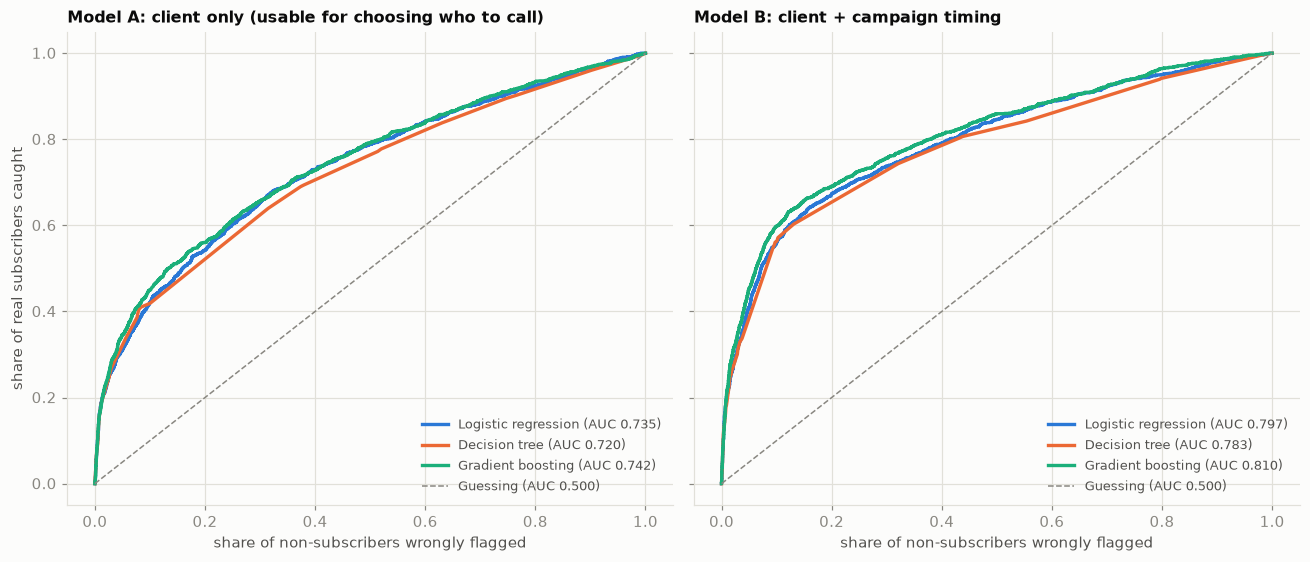

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), sharey=True)
colors = {'Logistic regression': BLUE, 'Decision tree': ORANGE, 'Gradient boosting': '#1baf7a'}
for ax, (v, ttl) in zip(axes, [('A', 'Model A: client only (usable for choosing who to call)'), ('B', 'Model B: client + campaign timing')]):
    for name, f in fits[v].items():
        fpr, tpr, _ = roc_curve(y_test, f['score'])
        ax.plot(fpr, tpr, color=colors[name], lw=2.2, label=f"{name} (AUC {roc_auc_score(y_test, f['score']):.3f})")
    ax.plot([0, 1], [0, 1], color=MUTED, ls='--', lw=1, label='Guessing (AUC 0.500)')
    ax.set_xlabel('share of non-subscribers wrongly flagged'); ax.set_title(ttl, fontsize=10.5); ax.legend(frameon=False, loc='lower right', fontsize=8.5)
axes[0].set_ylabel('share of real subscribers caught')
plt.tight_layout()

### Lift / gains chart: what it means in business terms
Imagine the bank can only phone a limited share of its clients. We rank every test client by the model's score, call from the top down, and track what fraction of **all** the eventual subscribers we have reached.

- The **diagonal line** is calling clients in random order: calling 20% of clients reaches 20% of subscribers.
- A good model's curve rises **above the diagonal**. The gap is the benefit.
- **Lift** = (share of subscribers reached) ÷ (share of clients called). A lift of 3 at 20% means we reach three times as many subscribers as random calling would.

Model A: what happens if we only call the top X% of clients (random calling would give an 11.7% success rate)


subscribers reached  lift success rate of calls
model               clients called                                                
Logistic regression top 10%                        35%  3.52                 41.2%
                    top 20%                        50%  2.50                 29.3%
                    top 30%                        61%  2.04                 23.8%
                    top 50%                        77%  1.54                 18.0%
Decision tree       top 10%                        36%  3.59                 42.0%
                    top 20%                        48%  2.41                 28.2%
                    top 30%                        59%  1.97                 23.1%
                    top 50%                        74%  1.49                 17.4%
Gradient boosting   top 10%                        38%  3.77                 44.1%
                    top 20%                        52%  2.60                 30.4%
                    top 30%                        62%  2.06                 24.1%
                    top 50%                        77%  1.54                 18.0%

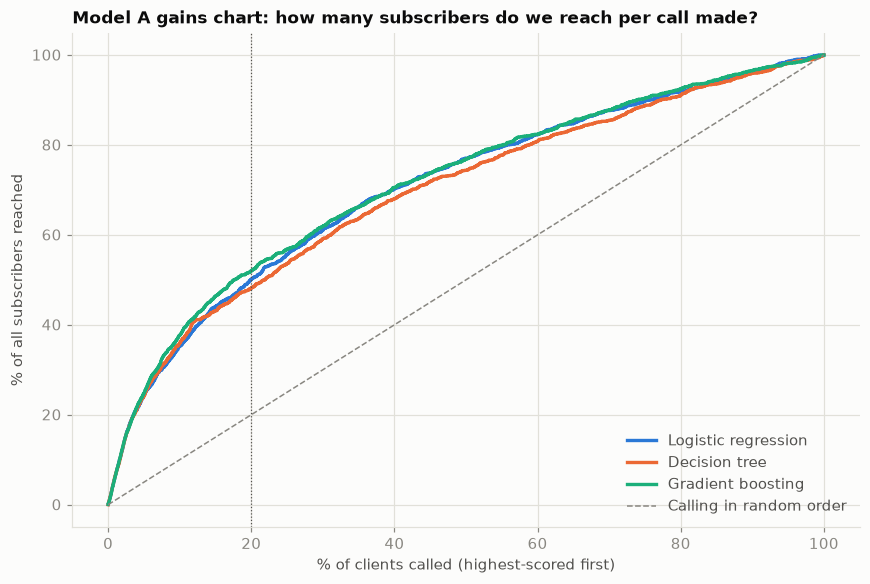

In [48]:
def gains(score, y):
    order = np.argsort(-np.asarray(score)); ys = np.asarray(y)[order]
    return np.arange(1, len(ys) + 1) / len(ys), np.cumsum(ys) / ys.sum()

fig, ax = plt.subplots(figsize=(8, 5.4))
for name in ['Logistic regression', 'Decision tree', 'Gradient boosting']:
    x, g = gains(fits['A'][name]['score'], y_test)
    ax.plot(x * 100, g * 100, color=colors[name], lw=2.2, label=f'{name}')
ax.plot([0, 100], [0, 100], color=MUTED, ls='--', lw=1, label='Calling in random order')
ax.axvline(20, color=INK2, lw=0.8, ls=':')
ax.set_xlabel('% of clients called (highest-scored first)'); ax.set_ylabel('% of all subscribers reached')
ax.set_title('Model A gains chart: how many subscribers do we reach per call made?'); ax.legend(frameon=False, loc='lower right')
plt.tight_layout()

rows = []
for name in ['Logistic regression', 'Decision tree', 'Gradient boosting']:
    x, g = gains(fits['A'][name]['score'], y_test)
    for pct in [10, 20, 30, 50]:
        i = int(len(x) * pct / 100) - 1
        rows.append({'model': name, 'clients called': f'top {pct}%', 'subscribers reached': f'{g[i]:.0%}', 'lift': round(g[i] / (pct / 100), 2),
                     'success rate of calls': f'{g[i] * y_test.sum() / (x[i] * len(x)):.1%}'})
print('Model A: what happens if we only call the top X% of clients (random calling would give an 11.7% success rate)')
pd.DataFrame(rows).set_index(['model', 'clients called'])

### What this means for the bank
Using the client-only model to rank clients (test set, never seen during training):

- Calling only the **top 10%** of clients reaches **35–38% of all subscribers**, with a success rate of **41–44%** per call (random calling gives 11.7%): a lift of about 3.5–3.8×.
- Calling the **top 20%** reaches **48–52%** of subscribers at a **28–30%** success rate (lift about 2.5×).
- Calling the **top 50%** reaches about **75–77%** of subscribers, so the bottom half of the list contains only about a quarter of them.

All three models are close, with gradient boosting slightly ahead. In other words, half the calls would capture three-quarters of the subscribers.

## Step 7: What did the best model learn?

Gradient boosting is hard to read directly, so we use two tools to look inside it.

**Permutation importance.** For each feature, we scramble its values randomly in the test set and see how much the model's AUC *drops*. If scrambling a feature wrecks the model, the model relied heavily on it; if nothing changes, the feature didn't matter. The bars show the AUC lost.

**Partial-dependence plots.** These show the *shape* of a feature's effect: hold everything else as it is, vary one feature across its range, and plot the average predicted subscription probability. This reveals curves that a simple table of averages can hide (such as the U-shape in age).

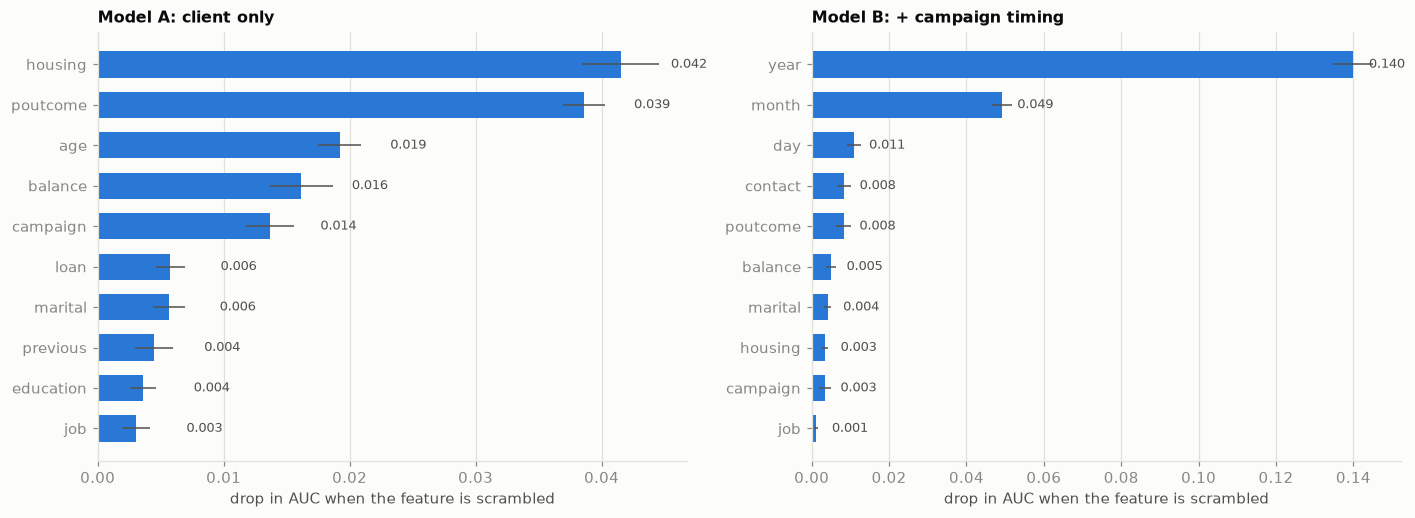

In [49]:
def perm_imp(f, ax, title):
    Xte = m.loc[idx_test, f['cols']]
    r = permutation_importance(f['pipe'], Xte, y_test, scoring='roc_auc', n_repeats=8, random_state=RS)
    s = pd.Series(r.importances_mean, index=f['cols']).sort_values().tail(10)
    sd = pd.Series(r.importances_std, index=f['cols'])[s.index]
    ax.barh(s.index, s.values, xerr=sd.values, color=BLUE, height=0.65, error_kw=dict(ecolor=INK2, lw=1))
    for i, v in enumerate(s.values): ax.text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=8.5, color=INK2)
    ax.set_title(title, fontsize=10.5); ax.set_xlabel('drop in AUC when the feature is scrambled'); ax.grid(axis='y', visible=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
perm_imp(fits['A']['Gradient boosting'], axes[0], 'Model A: client only')
perm_imp(fits['B']['Gradient boosting'], axes[1], 'Model B: + campaign timing')
plt.tight_layout()

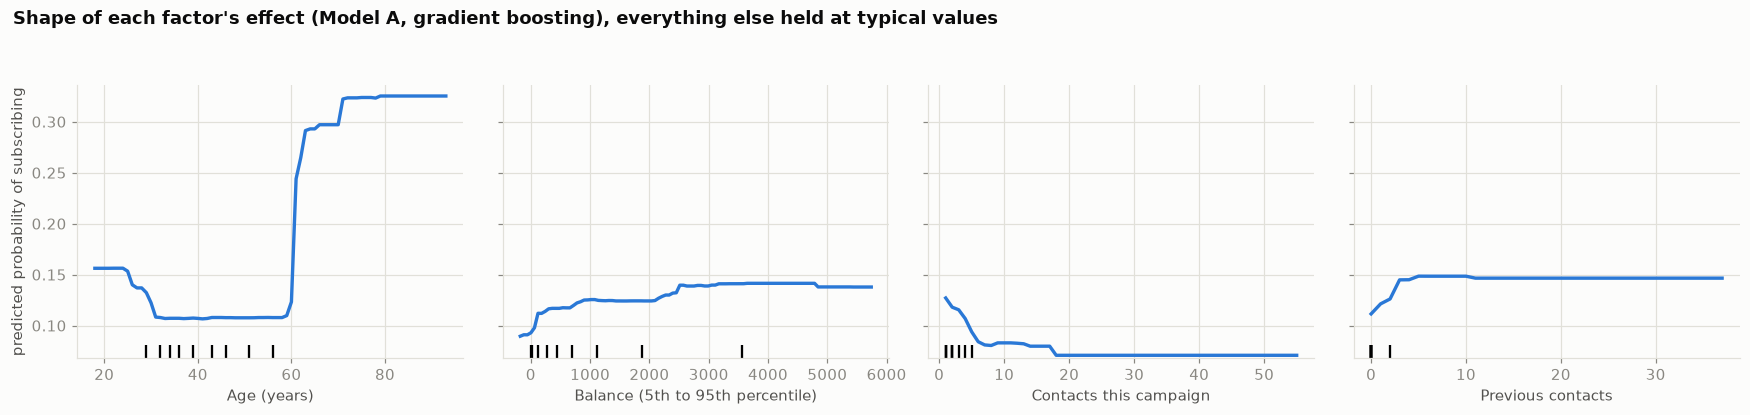

In [50]:
fA = fits['A']['Gradient boosting']
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
Xpd = m.loc[idx_test, fA['cols']].copy(); Xpd[A_NUM] = Xpd[A_NUM].astype(float)   # PDP requires float columns
PartialDependenceDisplay.from_estimator(fA['pipe'], Xpd, ['age', 'balance', 'campaign', 'previous'],
                                        kind='average', ax=axes, line_kw={'color': BLUE, 'lw': 2.2})
for ax, t in zip(axes, ['Age (years)', 'Balance (5th to 95th percentile)', 'Contacts this campaign', 'Previous contacts']):
    ax.set_xlabel(t); ax.set_ylabel('')
axes[0].set_ylabel('predicted probability of subscribing')
fig.suptitle('Shape of each factor\'s effect (Model A, gradient boosting), everything else held at typical values', x=0.01, ha='left', fontsize=12, fontweight='bold', color=INK)
plt.tight_layout(rect=[0, 0, 1, 0.92])

### What the best model learned
**Permutation importance (the bar charts above).** In Model A the most important features are **housing loan** (AUC drops 0.042 when scrambled) and **prior outcome** (0.039), followed by **age** (0.019), **balance** (0.016) and **number of attempts** (0.014). Job, education and marital status matter very little once those are known. In Model B, **year dominates everything** (0.140, over three times the next feature) and month is second (0.049). This is the clearest evidence that when timing is allowed, the model mostly learns *when* the call happened rather than anything about the client.

**Shape of the effects (partial-dependence plots).**
- **Age:** flat at about 11% from 30 to 59, higher (about 15%) under 25, then a **vertical jump at exactly 60 to around 30%**. A real life-stage effect would build gradually; a cliff at a round number looks like the bank deliberately targeting over-60s (for example a particular retirement or savings product) rather than clients naturally becoming more receptive.
- **Balance:** probability rises quickly up to about $1,000, more slowly after that, and flattens out by about $2,500. Having more than a few thousand adds little.
- **Contacts this campaign:** predicted probability falls from about 13% at the first call to about 8% by the fifth to eighth call, then stays flat. Repeated calling has diminishing returns.
- **Previous contacts:** a small rise from 0 to about 5, then flat.

## Step 8: The honesty check. Does it still work on *later* data?

Everything so far used a **random** split, which mixes 2008, 2009 and 2010 calls in both training and test sets. But in real life we would train on the past and use the model on the *future*. And we know the campaign changed a lot over time (the success rate went from 5% to 52%), so this is a tougher exam.

**How:** rows in the file are in time order, so we train on the **earliest 70%** of rows and test on the **latest 30%**. We then look at two things:
- **AUC**: can the model still *rank* clients correctly in a different period?
- **Average predicted rate vs actual rate**: does the model's overall sense of "how many will subscribe" match reality? Rankings can survive a change in the campaign, but the overall level usually won't. If the model predicts 8% but the real rate is 40%, its absolute probabilities can't be trusted, even if its ranking is fine.

In [51]:
cut = int(len(m) * 0.7)
t_train, t_test = m.index[:cut], m.index[cut:]
tfit = {'A': fit_all(False, t_train, t_test), 'B': fit_all(True, t_train, t_test)}
yt = m.loc[t_test, 'subscribed']
print(f'Train: first {cut:,} rows (subscribe rate {m.loc[t_train, "subscribed"].mean():.1%});  Test: last {len(t_test):,} rows (subscribe rate {yt.mean():.1%})\n')
rows = []
for v, label in [('A', 'A: client only'), ('B', 'B: + timing')]:
    for name in ['Logistic regression', 'Decision tree', 'Gradient boosting']:
        rows.append({'version': label, 'model': name,
                     'AUC random split': roc_auc_score(y_test, fits[v][name]['score']),
                     'AUC time split': roc_auc_score(yt, tfit[v][name]['score']),
                     'avg predicted rate (time split)': tfit[v][name]['score'].mean() * 100,
                     'actual rate (time split)': yt.mean() * 100})
time_res = pd.DataFrame(rows).set_index(['version', 'model'])
time_res.round(3)

Train: first 31,647 rows (subscribe rate 5.8%);  Test: last 13,564 rows (subscribe rate 25.4%)



AUC random split  AUC time split  avg predicted rate (time split)  actual rate (time split)
version        model                                                                                                           
A: client only Logistic regression             0.735           0.727                            7.414                    25.428
               Decision tree                   0.720           0.621                            9.082                    25.428
               Gradient boosting               0.742           0.690                            9.966                    25.428
B: + timing    Logistic regression             0.797           0.696                           11.939                    25.428
               Decision tree                   0.783           0.625                           11.631                    25.428
               Gradient boosting               0.810           0.632                           15.227                    25.428

### What the time check shows
We trained on the earliest 70% of rows (a 5.8% success rate) and tested on the latest 30% (a 25.4% success rate):

- **The simple client-only model holds up best:** logistic regression AUC goes from 0.735 to **0.727**, barely any loss. Gradient boosting drops to 0.690 and the decision tree to 0.621.
- **Adding timing makes things *worse* in the future:** Model B falls to 0.696 (logistic), 0.632 (gradient boosting) and 0.625 (tree), all below their Model A versions. The "improvement" in Step 6 was an illusion: the model learned what 2008 and early 2009 looked like and could not carry it forward.
- **The overall level is badly off.** Every model predicted an average success rate of 7–15% while the real rate was 25.4%, an underestimate of up to 3×. The models can still *rank* clients reasonably, but their probabilities would need to be recalibrated on recent data before being quoted as real likelihoods.

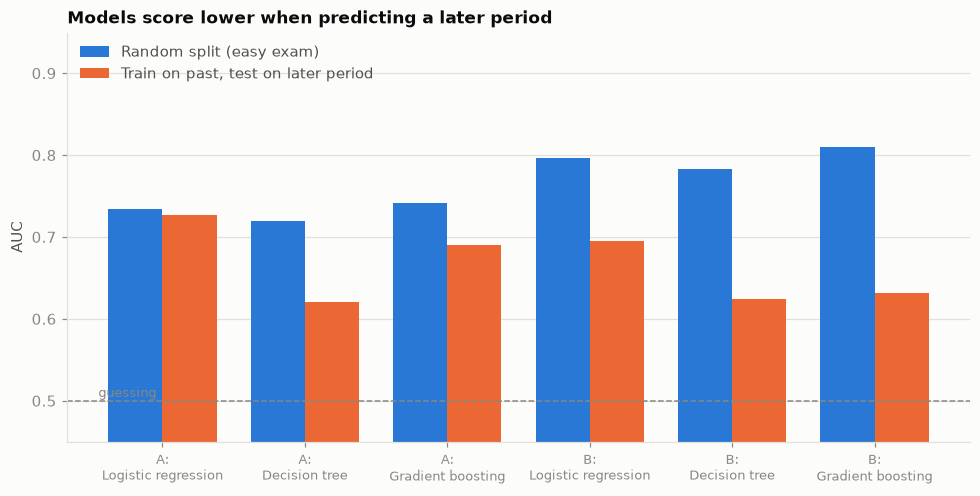

In [52]:
fig, ax = plt.subplots(figsize=(9, 4.6))
labels = [f'{v[0]}: {n}' for v, n in time_res.index]
x = np.arange(len(labels)); w = 0.38
ax.bar(x - w / 2, time_res['AUC random split'], w, color=BLUE, label='Random split (easy exam)')
ax.bar(x + w / 2, time_res['AUC time split'], w, color=ORANGE, label='Train on past, test on later period')
ax.axhline(0.5, color=MUTED, ls='--', lw=1); ax.text(-0.45, 0.505, 'guessing', ha='left', fontsize=8.5, color=MUTED)
ax.set_xticks(x); ax.set_xticklabels([l.replace(' ', '\n', 1) for l in labels], fontsize=8.5); ax.set_ylim(0.45, 0.95); ax.set_ylabel('AUC')
ax.set_title('Models score lower when predicting a later period'); ax.legend(frameon=False, loc='upper left'); ax.grid(axis='x', visible=False)
plt.tight_layout()

## Summary in plain English

**The question:** can we figure out, *before* making a call, which clients are likely to sign up for the term deposit?

**The short answer:** partly. We can do much better than guessing, but we can't predict any one person with confidence.

### What we found
1. **Some clients are clearly more likely to say yes.**
   - People who said yes to a *previous* campaign are by far the most likely to say yes again.
   - Clients without a housing loan or personal loan, clients over 60, and clients with higher bank balances are also more likely to sign up.
   - Every extra call to the same person makes a yes a little less likely.

2. **A simple model works nearly as well as a fancy one.** We tried three methods, from a basic flowchart to a complex "learning" model. The basic ones performed almost as well, so there's no need for anything complicated.

3. **It helps the bank save effort.** If the bank ranked clients with our model and called only the top 20%, it would reach about **half of all the people who sign up**, and the success rate per call would be about **2.5 times higher** than calling people at random. Calling the top half would reach about three-quarters of them.

4. **When you called matters as much as who you called.** The bank's approach changed a lot between 2008 and 2010: early on it called almost everyone and about 5% said yes; later it called a much better-chosen list and about half said yes. Some patterns we first spotted, such as "older clients say yes more" and "people without loans say yes more", turned out to be much weaker than they first looked once we took this into account. They're real, but they were exaggerated.

5. **Predictions go stale.** The model is good at putting clients in order from most to least likely. It is *not* good at predicting how many people will say yes overall, because the bank's success rate shifted so much over time. It would need updating with recent data before anyone relied on its exact percentages.

### Things to keep in mind
- **This shows links, not causes.** The bank chose whom to call, so we can't say that being over 60 *makes* someone more likely to sign up. The bank may simply have picked its best prospects. The sharp jump at exactly age 60 suggests the bank targeted that group on purpose.
- **We guessed the year.** The data has no dates, only months, so we worked out the year from the order of the rows.
- **Three years of data isn't much,** and the bank kept changing its strategy during that time.
- **The model is helpful but not perfect.** Plenty of people it ranks low still sign up, and plenty it ranks high still say no.

### What to do next
- Update the model using only the most recent data.
- Find out why age 60 is such a sharp dividing line (for example, a product aimed at retirees).
- Run a small test where some clients are chosen for calls at random. That's the only way to learn what really makes people say yes.